In [6]:
from __future__ import annotations
import os
import json
import numpy as np
from astropy.table import Table
from astropy.cosmology import FlatwCDM
import pandas as pd

import pymultinest
import matplotlib.pyplot as plt
#import corner
from getdist import plots, MCSamples
import scipy.optimize as op
import astropy.units as u
from scipy import stats
import scipy.optimize as op
from astropy import constants as const
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

/tmp/ipykernel_2021780/686557093.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


OK - figura guardada


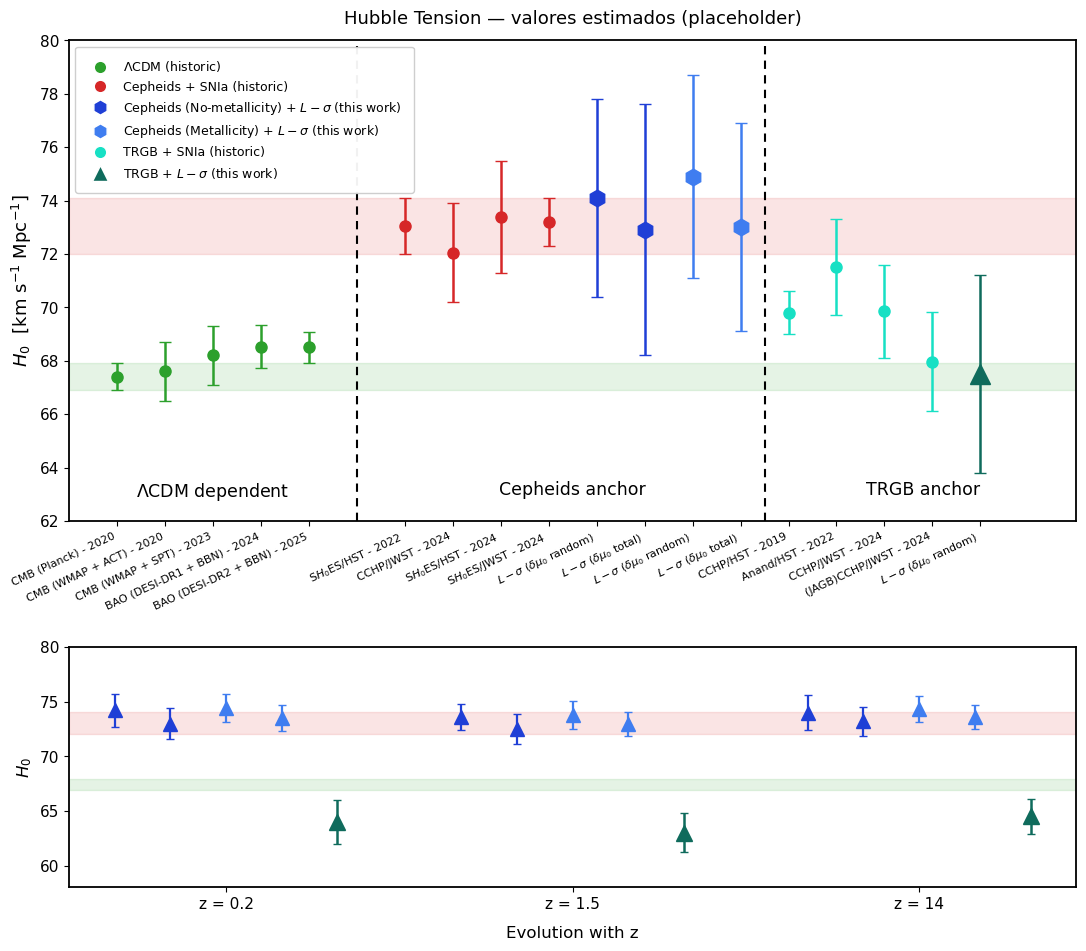

In [7]:
"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---
PLANCK_H0, PLANCK_ERR = 67.4, 0.5      # Planck 2018
SHOES_H0, SHOES_ERR = 73.04, 1.04        # SH0ES (Riess et al.)

# --- Bloque 1: Historic LambdaCDM / CMB (verde) ---
lcdm_labels = ["CMB (Planck) - 2020", "CMB (WMAP + ACT) - 2020", "CMB (WMAP + SPT) - 2023", "BAO (DESI-DR1 + BBN) - 2024", "BAO (DESI-DR2 + BBN) - 2025"]
lcdm_x = np.array([1, 2, 3, 4, 5])
lcdm_y = np.array([67.4, 
                   67.6, 
                   68.2, 
                   68.53, 
                   68.51])
lcdm_yerr = np.array([0.5, 
                      1.1, 
                      1.1, 
                      0.80, 
                      0.58])



# --- Bloque 2: Cefeidas (Distance Ladder=rojo, This work=azul) ---
ceph_labels = [r"S$H_0$ES/HST - 2022","CCHP/JWST - 2024", r"S$H_0$ES/HST - 2024", r"S$H_0$ES/JWST - 2024", 
               r"$L-\sigma$ ($\delta \mu_0$ random)", r"$L-\sigma$ ($\delta \mu_0$ total)", 
               r"$L-\sigma$ ($\delta \mu_0$ random)", r"$L-\sigma$ ($\delta \mu_0$ total)"]
ceph_x = np.array([7, 8, 9, 10, 11, 12, 13, 14])
ceph_y = np.array([73.04, 
                   72.05, 
                   73.40, 
                   73.20, 
                   74.10, 
                   72.90, 
                   74.90, 
                   73.00])
ceph_yerr = np.array([1.04, 
                      1.86, 
                      2.10, 
                      0.90, 
                      3.7, 
                      4.7, 
                      3.8, 
                      3.9])
# tipo: 'dl' = Distance Ladder (rojo, circulo), 'nometal'/'metal' = This work (azul, triangulo)
ceph_kind = ["dl", "dl", "dl", "dl", "nometal", "nometal", "metal", "metal"]







# --- Bloque 3: TRGB (Historic=cian, This work=verde oscuro) ---
trgb_labels = ["CCHP/HST - 2019","Anand/HST - 2022", "CCHP/JWST - 2024", "(JAGB)CCHP/JWST - 2024", 
               r"$L-\sigma$ ($\delta \mu_0$ random)"]
trgb_x = np.array([15, 16, 17, 18, 19])
trgb_y = np.array([69.80, 
                   71.50, 
                   69.85, 
                   67.96, 
                   67.50])
trgb_yerr = np.array([0.80, 
                      1.80, 
                      1.75, 
                      1.85, 
                      3.7])
trgb_kind = ["hist", "hist", "hist", "hist", "thiswork"]











# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)

eta_data = {
    0.2: {
        "nometal": [(74.2, 1.5), (73.0, 1.4)],
        "metal":   [(74.4, 1.3), (73.5, 1.2)],
        "trgb":    [(64.0, 2.0)],
    },
    1.5: {
        "nometal": [(73.6, 1.2), (72.5, 1.4)],
        "metal":   [(73.8, 1.3), (73.0, 1.1)],
        "trgb":    [(63.0, 1.8)],
    },
    14: {
        "nometal": [(74.0, 1.6), (73.2, 1.3)],
        "metal":   [(74.3, 1.2), (73.6, 1.1)],
        "trgb":    [(64.5, 1.6)],
    },
}

# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})

fig = plt.figure(figsize=(13, 11))
gs = GridSpec(2, 1, height_ratios=[2.0, 1.0], hspace=0.35)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1])

# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas
for ax in (ax_top, ax_bot):
    ax.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
               color=COLOR_LCDM, alpha=0.12, zorder=0)
    ax.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
               color=COLOR_DL, alpha=0.12, zorder=0)
    #ax.axhline(PLANCK_H0, color=COLOR_LCDM, lw=1.0, alpha=0.5, zorder=0)
    #ax.axhline(SHOES_H0, color=COLOR_DL, lw=1.0, alpha=0.5, zorder=0)

# --- Bloque historic LCDM (circulos verdes) ---
ax_top.errorbar(lcdm_x, lcdm_y, yerr=lcdm_yerr, fmt="o", color=COLOR_LCDM,
                 ecolor=COLOR_LCDM, elinewidth=1.8, capsize=4, markersize=8,
                 zorder=3)

# --- Bloque Cefeidas (rojo=dl circulo, azul=this work triangulo) ---
for x, y, yerr, kind in zip(ceph_x, ceph_y, ceph_yerr, ceph_kind):
    if kind == "dl":
        ax_top.errorbar(x, y, yerr=yerr, fmt="o", color=COLOR_DL,
                         ecolor=COLOR_DL, elinewidth=1.8, capsize=4,
                         markersize=8, zorder=3)
    elif kind == "nometal":
        ax_top.errorbar(x, y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.8, capsize=4,
                         markersize=12, zorder=3)
    elif kind == "metal":
        ax_top.errorbar(x, y, yerr=yerr, fmt="h", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.8, capsize=4,
                         markersize=12, zorder=3)

# --- Bloque TRGB (cian=historic circulo, verde oscuro=this work triangulo) ---
for x, y, yerr, kind in zip(trgb_x, trgb_y, trgb_yerr, trgb_kind):
    if kind == "hist":
        ax_top.errorbar(x, y, yerr=yerr, fmt="o", color=COLOR_TRGB_HIST,
                         ecolor=COLOR_TRGB_HIST, elinewidth=1.8, capsize=4,
                         markersize=8, zorder=3)
    else:
        ax_top.errorbar(x, y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=4,
                         markersize=14, zorder=3)

# Separadores verticales punteados entre bloques
ax_top.axvline(6, color="black", ls=(0, (4, 3)), lw=1.5, zorder=2)
ax_top.axvline(14.5, color="black", ls=(0, (4, 3)), lw=1.5, zorder=2)

# Eje x: etiquetas de grupo
lcdm_center = float(np.mean(lcdm_x))   # centro real del bloque LCDM
ceph_center = float(np.mean(ceph_x))   # centro real del bloque Cefeidas
trgb_center = float(np.mean(trgb_x))   # centro real del bloque TRGB
ax_top.set_xticks(list(lcdm_x) + list(ceph_x) + list(trgb_x))
ax_top.set_xticklabels(lcdm_labels + ceph_labels + trgb_labels,
                       rotation=25, ha="right", fontsize=8.0)




ax_top.text(
    lcdm_center, 63.5,
    r"$\Lambda$CDM dependent",
    ha="center", va="top", fontsize=12.5
)

ax_top.text(
    ceph_center, 63.5,
    r"Cepheids anchor",
    ha="center", va="top", fontsize=12.5
)

ax_top.text(
    trgb_center+0.8, 63.5,
    r"TRGB anchor",
    ha="center", va="top", fontsize=12.5
)




ax_top.set_ylabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=13)
ax_top.set_ylim(62, 80)
ax_top.set_xlim(0, 21)
ax_top.set_title("Hubble Tension — valores estimados (placeholder)", fontsize=13, pad=12)

# ---------------------------------------------------------------
# 4. LEYENDA (replicando el cuadro del boceto)
# ---------------------------------------------------------------

legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_LCDM,
           markersize=9, label=r"$\Lambda$CDM (historic)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_DL,
           markersize=9, label="Cepheids + SNIa (historic)"),
    Line2D([0], [0], marker="h", color="w", markerfacecolor=COLOR_NOMETAL,
           markersize=11, label=r"Cepheids (No-metallicity) + $L-\sigma$ (this work)"),
    Line2D([0], [0], marker="h", color="w", markerfacecolor=COLOR_METAL,
           markersize=11, label=r"Cepheids (Metallicity) + $L-\sigma$ (this work)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_TRGB_HIST,
           markersize=9, label="TRGB + SNIa (historic)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_TRGB_NEW,
           markersize=11, label=r"TRGB + $L-\sigma$ (this work)"),
]
ax_top.legend(handles=legend_elems, loc="upper left", fontsize=9.0,
              framealpha=0.95, ncol=1, title="", borderpad=1.0)

# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=12, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([f"z = {z}" for z in z_groups])
ax_bot.set_ylabel(r"$H_0$", fontsize=12)
ax_bot.set_ylim(58, 80)
ax_bot.set_xlabel("Evolution with z", fontsize=12, labelpad=10)



plt.tight_layout()
plt.savefig("hubble_tension.png", dpi=180, bbox_inches="tight")
print("OK - figura guardada")

OK - figura guardada


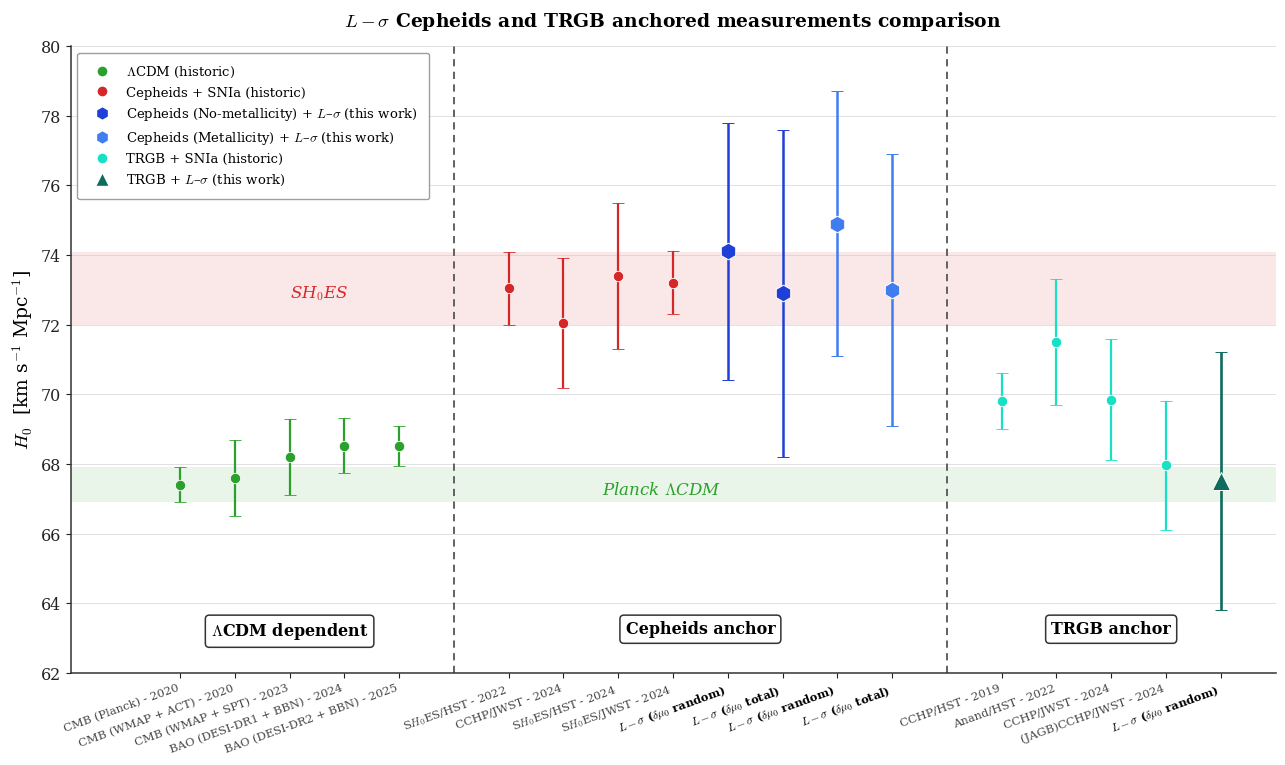

In [8]:
"""
Hubble Tension plot - version "paper-like".
Datos reales de Holman (Planck, WMAP, DESI, SH0ES, CCHP, L-sigma).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS
# ---------------------------------------------------------------

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Bloque 1: LambdaCDM / CMB+BAO (verde) ---
lcdm_labels = ["CMB (Planck) - 2020", "CMB (WMAP + ACT) - 2020",
               "CMB (WMAP + SPT) - 2023", "BAO (DESI-DR1 + BBN) - 2024",
               "BAO (DESI-DR2 + BBN) - 2025"]
lcdm_x = np.array([1, 1.5, 2, 2.5, 3])
lcdm_y = np.array([67.4, 
                   67.6, 
                   68.2, 
                   68.53, 
                   68.51])
lcdm_yerr = np.array([0.5, 
                      1.1, 
                      1.1, 
                      0.80, 
                      0.58])

# --- Bloque 2: Cefeidas (Distance Ladder=rojo, This work=azul) ---
ceph_labels = [r"S$H_0$ES/HST - 2022", "CCHP/JWST - 2024",
               r"S$H_0$ES/HST - 2024", r"S$H_0$ES/JWST - 2024",
               r"$L-\sigma$ ($\delta \mu_0$ random)", r"$L-\sigma$ ($\delta \mu_0$ total)",
               r"$L-\sigma$ ($\delta \mu_0$ random)", r"$L-\sigma$ ($\delta \mu_0$ total)"]
ceph_x = np.array([4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5])
ceph_y = np.array([73.04, 
                   72.05, 
                   73.40, 
                   73.20, 
                   74.10, 
                   72.90, 
                   74.90, 
                   73.00])
ceph_yerr = np.array([1.04, 
                      1.86, 
                      2.10, 
                      0.90, 
                      3.7, 
                      4.7, 
                      3.8, 
                      3.9])
ceph_kind = ["dl", "dl", "dl", "dl", "nometal", "nometal", "metal", "metal"]

# --- Bloque 3: TRGB (Historic=cian, This work=verde oscuro) ---
trgb_labels = ["CCHP/HST - 2019", "Anand/HST - 2022", "CCHP/JWST - 2024",
               "(JAGB)CCHP/JWST - 2024", r"$L-\sigma$ ($\delta \mu_0$ random)"]
trgb_x = np.array([8.5, 9, 9.5, 10, 10.5])
trgb_y = np.array([69.80, 
                   71.50, 
                   69.85, 
                   67.96, 
                   67.50])
trgb_yerr = np.array([0.80, 
                      1.80, 
                      1.75, 
                      1.85, 
                      3.7])
trgb_kind = ["hist", "hist", "hist", "hist", "thiswork"]

# Mascara global: que ticks van en negrita (todo lo que sea "this work" / L-sigma)
all_x = np.concatenate([lcdm_x, ceph_x, trgb_x])
all_labels = lcdm_labels + ceph_labels + trgb_labels
all_kind = (["lcdm"] * len(lcdm_x)) + ceph_kind + trgb_kind
bold_mask = [k in ("nometal", "metal", "thiswork") for k in all_kind]

# ---------------------------------------------------------------
# 2. ESTILO "PAPER-LIKE"
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"
COLOR_DL = "#d62728"
COLOR_TRGB_HIST = "#17e0c4"
COLOR_NOMETAL = "#1f3fd6"
COLOR_METAL = "#3f7df0"
COLOR_TRGB_NEW = "#0f6b5c"

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",       # Computer Modern, estilo LaTeX
    "font.size": 11.5,
    "axes.linewidth": 1.1,
    "axes.edgecolor": "#333333",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, ax_top = plt.subplots(figsize=(13, 7.8))

# ---------------------------------------------------------------
# 3. BANDAS DE REFERENCIA
# ---------------------------------------------------------------

ax_top.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
               color=COLOR_LCDM, alpha=0.10, zorder=0, lw=0)
ax_top.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
               color=COLOR_DL, alpha=0.10, zorder=0, lw=0)
#ax_top.axhline(PLANCK_H0, color=COLOR_LCDM, lw=1.0, alpha=0.55, zorder=1)
#ax_top.axhline(SHOES_H0, color=COLOR_DL, lw=1.0, alpha=0.55, zorder=1)

# Grid horizontal sutil, sin grid vertical (estilo paper)
ax_top.yaxis.grid(True, color="#cccccc", lw=0.6, alpha=0.7, zorder=0)
ax_top.set_axisbelow(True)

# ---------------------------------------------------------------
# 4. DATOS
# ---------------------------------------------------------------

ax_top.errorbar(lcdm_x, lcdm_y, yerr=lcdm_yerr, fmt="o", color=COLOR_LCDM,
                 ecolor=COLOR_LCDM, elinewidth=1.6, capsize=4, capthick=1.4,
                 markersize=7.5, markeredgecolor="white", markeredgewidth=0.6,
                 zorder=3)

for x, y, yerr, kind in zip(ceph_x, ceph_y, ceph_yerr, ceph_kind):
    if kind == "dl":
        ax_top.errorbar(x, y, yerr=yerr, fmt="o", color=COLOR_DL,
                         ecolor=COLOR_DL, elinewidth=1.6, capsize=4, capthick=1.4,
                         markersize=7.5, markeredgecolor="white", markeredgewidth=0.6,
                         zorder=3)
    elif kind == "nometal":
        ax_top.errorbar(x, y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.8, capsize=4, capthick=1.5,
                         markersize=12, markeredgecolor="white", markeredgewidth=0.7,
                         zorder=4)
    elif kind == "metal":
        ax_top.errorbar(x, y, yerr=yerr, fmt="h", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.8, capsize=4, capthick=1.5,
                         markersize=12, markeredgecolor="white", markeredgewidth=0.7,
                         zorder=4)

for x, y, yerr, kind in zip(trgb_x, trgb_y, trgb_yerr, trgb_kind):
    if kind == "hist":
        ax_top.errorbar(x, y, yerr=yerr, fmt="o", color=COLOR_TRGB_HIST,
                         ecolor=COLOR_TRGB_HIST, elinewidth=1.6, capsize=4, capthick=1.4,
                         markersize=7.5, markeredgecolor="white", markeredgewidth=0.6,
                         zorder=3)
    else:
        ax_top.errorbar(x, y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.9, capsize=4.5, capthick=1.6,
                         markersize=13.5, markeredgecolor="white", markeredgewidth=0.7,
                         zorder=4)

# Separadores verticales entre bloques
ax_top.axvline(3.5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_top.axvline(8.0, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

# ---------------------------------------------------------------
# 5. EJE X: ticks rotados + negrita selectiva para L-sigma / this work
# ---------------------------------------------------------------

ax_top.set_xticks(all_x)
tick_labels = ax_top.set_xticklabels(all_labels, rotation=20, ha="right", fontsize=8.3)

for lbl, bold in zip(tick_labels, bold_mask):
    if bold:
        lbl.set_fontweight("bold")
        lbl.set_color("#000000")
    else:
        lbl.set_color("#444444")

ax_top.set_ylabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=13.5)
ax_top.set_ylim(62, 80)
ax_top.set_xlim(0, 11)
ax_top.set_title(r"$L-\sigma$ Cepheids and TRGB anchored measurements comparison",
                  fontsize=13.5, pad=14, fontweight="bold")

# Quitar spines superior/derecho (estilo paper limpio)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)

# ---------------------------------------------------------------
# 6. CAJAS DE TITULO DE BLOQUE (ACDM dependent / Cepheids anchor / TRGB anchor)
# ---------------------------------------------------------------

lcdm_center = float(np.mean(lcdm_x))
ceph_center = float(np.mean(ceph_x))
trgb_center = float(np.mean(trgb_x))

box_style = dict(boxstyle="round,pad=0.35,rounding_size=0.25",
                  facecolor="white", edgecolor="#333333", linewidth=1.1)

ax_top.text(lcdm_center, 63.5, r"$\Lambda$CDM dependent",
            ha="center", va="top", fontsize=11.5, fontweight="bold",
            bbox=box_style, zorder=5)

ax_top.text(ceph_center, 63.5, "Cepheids anchor",
            ha="center", va="top", fontsize=11.5, fontweight="bold",
            bbox=box_style, zorder=5)

ax_top.text(trgb_center, 63.5, "TRGB anchor",
            ha="center", va="top", fontsize=11.5, fontweight="bold",
            bbox=box_style, zorder=5)

# Etiquetas discretas de las bandas de referencia, dentro del eje a la izquierda
ax_top.text(ceph_center-0.9, PLANCK_H0 - 0.4, r"Planck $\Lambda$CDM", color=COLOR_LCDM,
            fontsize=12, va="bottom", ha="left", style="italic")
ax_top.text(lcdm_center, SHOES_H0 - 0.4, r"SH$_0$ES", color=COLOR_DL,
            fontsize=12, va="bottom", ha="left", style="italic")

# ---------------------------------------------------------------
# 7. LEYENDA
# ---------------------------------------------------------------

legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_LCDM,
           markeredgecolor="white", markersize=8, label=r"$\Lambda$CDM (historic)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_DL,
           markeredgecolor="white", markersize=8, label="Cepheids + SNIa (historic)"),
    Line2D([0], [0], marker="h", color="w", markerfacecolor=COLOR_NOMETAL,
           markeredgecolor="white", markersize=10,
           label=r"Cepheids (No-metallicity) + $L$–$\sigma$ (this work)"),
    Line2D([0], [0], marker="h", color="w", markerfacecolor=COLOR_METAL,
           markeredgecolor="white", markersize=10,
           label=r"Cepheids (Metallicity) + $L$–$\sigma$ (this work)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_TRGB_HIST,
           markeredgecolor="white", markersize=8, label="TRGB + SNIa (historic)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_TRGB_NEW,
           markeredgecolor="white", markersize=10,
           label=r"TRGB + $L$–$\sigma$ (this work)"),
]
leg = ax_top.legend(handles=legend_elems, loc="upper left", # bbox_to_anchor=(1.01, 1.0),
                     fontsize=9.5, framealpha=0.95, ncol=1, borderpad=0.9,
                     handletextpad=0.8, edgecolor="#999999")
#leg.get_frame().set_linewidth(0.8)



plt.tight_layout()
plt.savefig("hubble_tension_v2.png", dpi=1500, bbox_inches="tight",transparent=True)
print("OK - figura guardada")

OK - figura vertical guardada


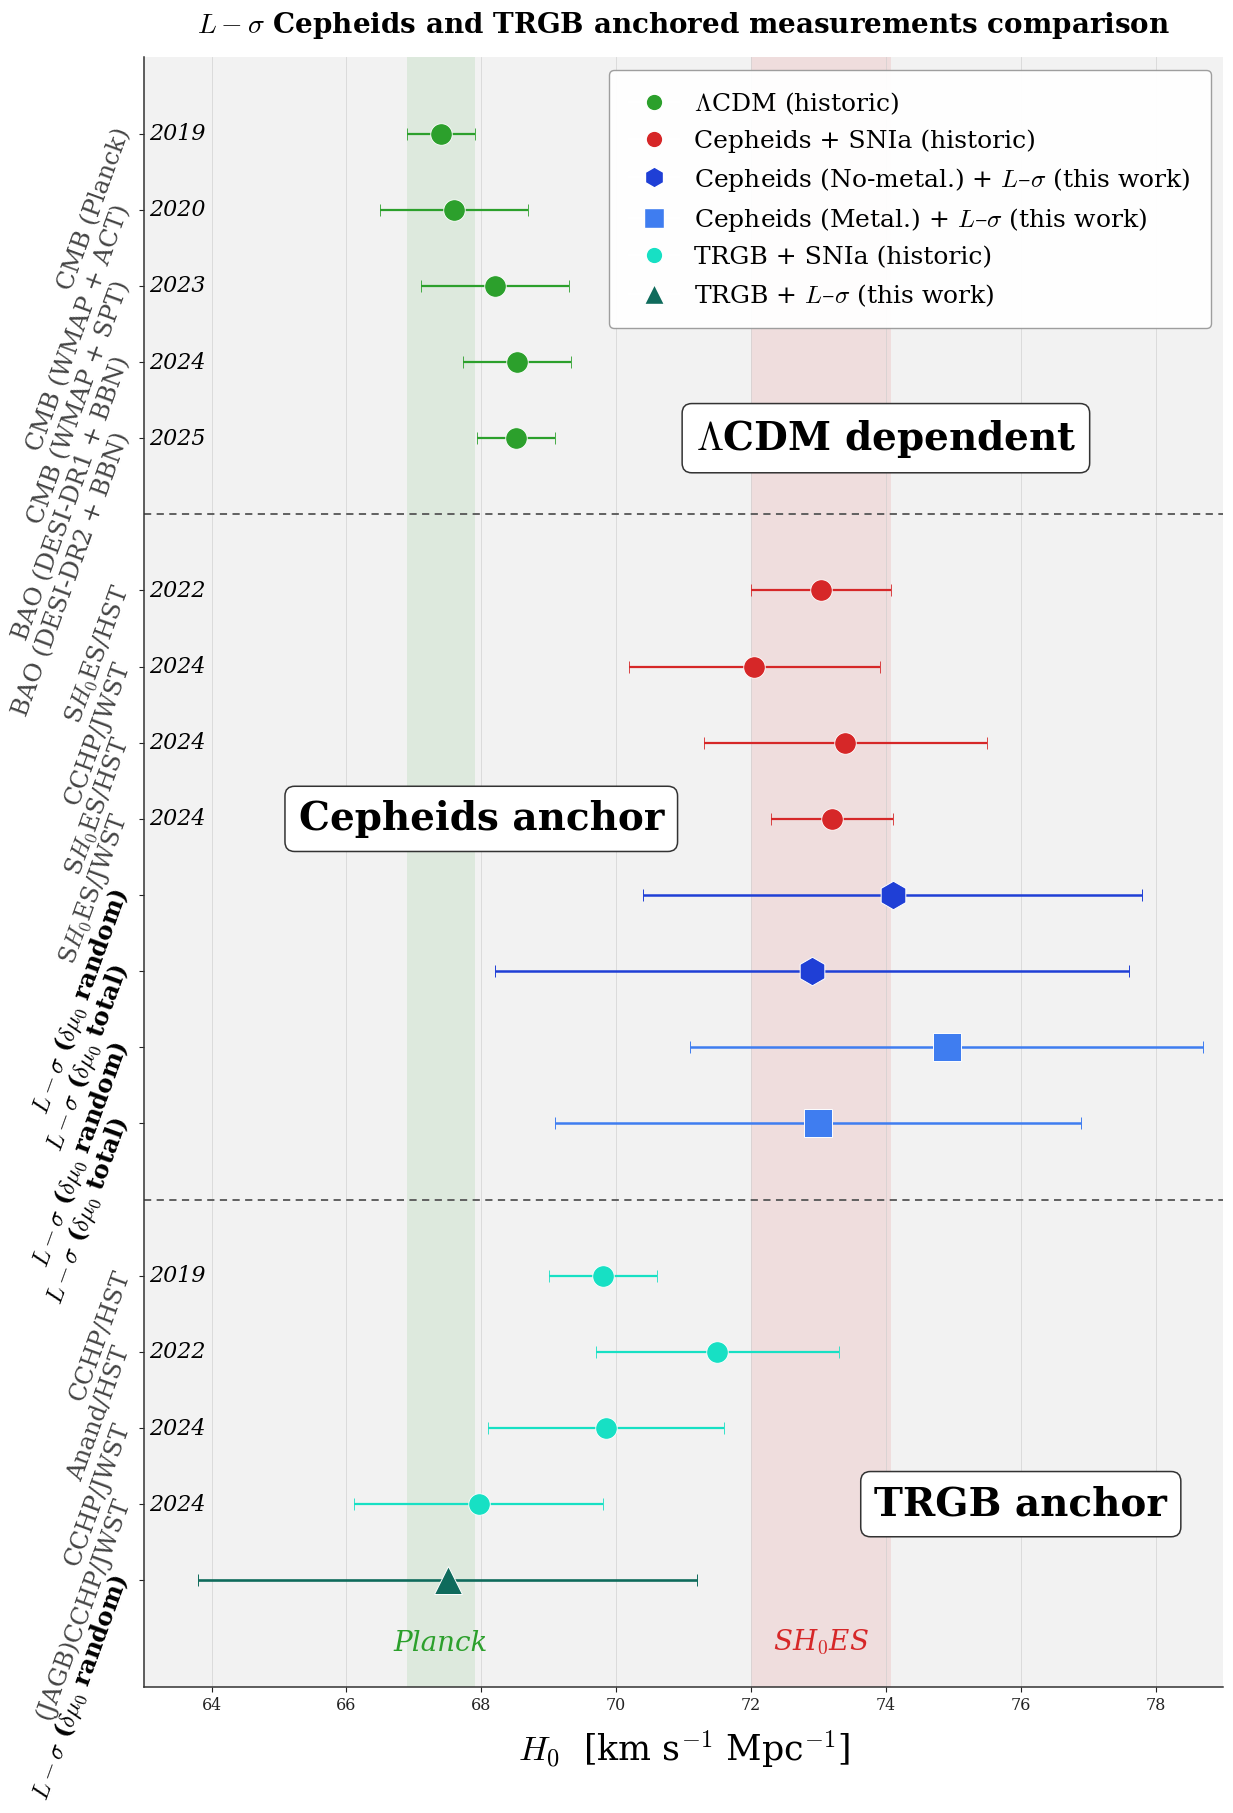

In [9]:
"""
Hubble Tension plot - version "paper-like" VERTICAL.
Datos reales de Holman (Planck, WMAP, DESI, SH0ES, CCHP, L-sigma).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS
# ---------------------------------------------------------------

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Bloque 1: LambdaCDM / CMB+BAO (verde) ---
lcdm_labels = ["CMB (Planck)", "CMB (WMAP + ACT)",
               "CMB (WMAP + SPT)", "BAO (DESI-DR1 + BBN)",
               "BAO (DESI-DR2 + BBN)"]
# Invertimos el orden de las posiciones para que se lea de arriba a abajo
lcdm_x = np.array([17, 16.5, 16.0, 15.5, 15.0])
lcdm_y = np.array([67.4, 67.6, 68.2, 68.53, 68.51])
lcdm_yerr = np.array([0.5, 1.1, 1.1, 0.80, 0.58])

# --- Bloque 2: Cefeidas (Distance Ladder=rojo, This work=azul) ---
ceph_labels = [r"S$H_0$ES/HST", "CCHP/JWST",
               r"S$H_0$ES/HST", r"S$H_0$ES/JWST",
               r"$L-\sigma$ ($\delta \mu_0$ random)", r"$L-\sigma$ ($\delta \mu_0$ total)",
               r"$L-\sigma$ ($\delta \mu_0$ random)", r"$L-\sigma$ ($\delta \mu_0$ total)"]
ceph_x = np.array([14.0, 13.5, 13.0, 12.5, 12.0, 11.5, 11.0, 10.5])
ceph_y = np.array([73.04, 72.05, 73.40, 73.20, 74.10, 72.90, 74.90, 73.00])
ceph_yerr = np.array([1.04, 1.86, 2.10, 0.90, 3.7, 4.7, 3.8, 3.9])
ceph_kind = ["dl", "dl", "dl", "dl", "nometal", "nometal", "metal", "metal"]

# --- Bloque 3: TRGB (Historic=cian, This work=verde oscuro) ---
trgb_labels = ["CCHP/HST", "Anand/HST", "CCHP/JWST",
               "(JAGB)CCHP/JWST", r"$L-\sigma$ ($\delta \mu_0$ random)"]
trgb_x = np.array([9.5, 9.0, 8.5, 8.0, 7.5])
trgb_y = np.array([69.80, 71.50, 69.85, 67.96, 67.50])
trgb_yerr = np.array([0.80, 1.80, 1.75, 1.85, 3.7])
trgb_kind = ["hist", "hist", "hist", "hist", "thiswork"]



# Concatenamos manteniendo el nuevo orden vertical (de arriba a abajo)
all_x = np.concatenate([lcdm_x, ceph_x, trgb_x])
all_labels = lcdm_labels + ceph_labels + trgb_labels
all_kind = (["lcdm"] * len(lcdm_x)) + ceph_kind + trgb_kind
bold_mask = [k in ("nometal", "metal", "thiswork") for k in all_kind]

# ---------------------------------------------------------------
# 2. ESTILO "PAPER-LIKE"
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"
COLOR_DL = "#d62728"
COLOR_TRGB_HIST = "#17e0c4"
COLOR_NOMETAL = "#1f3fd6"
COLOR_METAL = "#3f7df0"
COLOR_TRGB_NEW = "#0f6b5c"

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",       
    "font.size": 11.5,
    "axes.linewidth": 1.1,
    "axes.edgecolor": "#333333",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 316.89
target_height_mm = 467.83


# Invertimos las proporciones de la figura para hacerla alta
fig, ax = plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))

# ---------------------------------------------------------------
# 3. BANDAS DE REFERENCIA (Ahora verticales: axvspan)
# ---------------------------------------------------------------

ax.axvspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
           color=COLOR_LCDM, alpha=0.10, zorder=0, lw=0)
ax.axvspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
           color=COLOR_DL, alpha=0.10, zorder=0, lw=0)

# Grid vertical sutil, sin grid horizontal
ax.xaxis.grid(True, color="#cccccc", lw=0.6, alpha=0.7, zorder=0)
ax.set_axisbelow(True)


# Separadores horizontales entre bloques (ahora axhline)
ax.axhline(14.5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax.axhline(10.0, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)


# ---------------------------------------------------------------
# 4. DATOS (Se mapea el valor en X y la posición del tick en Y)
# ---------------------------------------------------------------

# Bloque 1: LambdaCDM
ax.errorbar(lcdm_y, lcdm_x, xerr=lcdm_yerr, fmt="o", color=COLOR_LCDM,
            ecolor=COLOR_LCDM, elinewidth=1.6, capsize=4, capthick=1.4,
            markersize=15.5, markeredgecolor="white", markeredgewidth=0.6,
            zorder=3)

# Bloque 2: Cefeidas
for x_pos, y_val, x_err, kind in zip(ceph_x, ceph_y, ceph_yerr, ceph_kind):
    if kind == "dl":
        ax.errorbar(y_val, x_pos, xerr=x_err, fmt="o", color=COLOR_DL,
                    ecolor=COLOR_DL, elinewidth=1.6, capsize=4, capthick=1.4,
                    markersize=15.5, markeredgecolor="white", markeredgewidth=0.6,
                    zorder=3)
    elif kind == "nometal":
        ax.errorbar(y_val, x_pos, xerr=x_err, fmt="h", color=COLOR_NOMETAL,
                    ecolor=COLOR_NOMETAL, elinewidth=1.8, capsize=4, capthick=1.5,
                    markersize=20.5, markeredgecolor="white", markeredgewidth=0.7,
                    zorder=4)
    elif kind == "metal":
        ax.errorbar(y_val, x_pos, xerr=x_err, fmt="s", color=COLOR_METAL,
                    ecolor=COLOR_METAL, elinewidth=1.8, capsize=4, capthick=1.5,
                    markersize=20.5, markeredgecolor="white", markeredgewidth=0.7,
                    zorder=4)

# Bloque 3: TRGB
for x_pos, y_val, x_err, kind in zip(trgb_x, trgb_y, trgb_yerr, trgb_kind):
    if kind == "hist":
        ax.errorbar(y_val, x_pos, xerr=x_err, fmt="o", color=COLOR_TRGB_HIST,
                    ecolor=COLOR_TRGB_HIST, elinewidth=1.6, capsize=4, capthick=1.4,
                    markersize=15.5, markeredgecolor="white", markeredgewidth=0.6,
                    zorder=3)
    else:
        ax.errorbar(y_val, x_pos, xerr=x_err, fmt="^", color=COLOR_TRGB_NEW,
                    ecolor=COLOR_TRGB_NEW, elinewidth=1.9, capsize=4.5, capthick=1.6,
                    markersize=20.5, markeredgecolor="white", markeredgewidth=0.7,
                    zorder=4)



# ---------------------------------------------------------------
# 5. CONFIGURACIÓN DE EJES Y FORMATO
# ---------------------------------------------------------------

# El eje X ahora maneja las escalas de H0
ax.set_xlabel(r"$H_0$  [km s$^{-1}$ Mpc$^{-1}$]", fontsize=25, labelpad=10)
ax.set_xlim(63, 79)

# El eje Y maneja los experimentos
ax.set_yticks(all_x)
tick_labels = ax.set_yticklabels(all_labels, fontsize=17.5, rotation=70)
ax.set_ylim(6.8, 17.5)

for lbl, bold in zip(tick_labels, bold_mask):
    if bold:
        lbl.set_fontweight("bold")
        lbl.set_color("#000000")
    else:
        lbl.set_color("#444444")

ax.set_title(r"$L-\sigma$ Cepheids and TRGB anchored measurements comparison",
             fontsize=20, pad=18, fontweight="bold")

# Quitar spines superior/derecho
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------------------------------
# 6. CAJAS DE TÍTULO DE BLOQUE (Alineadas verticalmente a la derecha)
# ---------------------------------------------------------------

lcdm_center = float(np.mean(lcdm_x))
ceph_center = float(np.mean(ceph_x))
trgb_center = float(np.mean(trgb_x))

box_style = dict(boxstyle="round,pad=0.35,rounding_size=0.25",
                 facecolor="white", edgecolor="#333333", linewidth=1.1)

# Se colocan en X=78.5 para que queden alineadas como etiquetas de sección limpia
ax.text(74, 15, r"$\Lambda$CDM dependent",
        ha="center", va="center", fontsize=28, fontweight="bold",
        bbox=box_style, zorder=5, rotation=0)

ax.text(68, 12.5, "Cepheids anchor",
        ha="center", va="center", fontsize=28, fontweight="bold",
        bbox=box_style, zorder=5, rotation=0)

ax.text(76, 8.0, "TRGB anchor",
        ha="center", va="center", fontsize=28, fontweight="bold",
        bbox=box_style, zorder=5, rotation=0)

# Etiquetas discretas de las bandas de referencia (ajustadas al nuevo flujo)
ax.text(PLANCK_H0, 7.0, r"Planck", color=COLOR_LCDM,
        fontsize=20, va="bottom", ha="center", style="italic", rotation=0)
ax.text(SHOES_H0, 7.0, r"SH$_0$ES", color=COLOR_DL,
        fontsize=20, va="bottom", ha="center", style="italic", rotation=0)


# LambdaCDM years

ax.text(63.5, 17.0, r"2019", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 16.5, r"2020", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 16.0, r"2023", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 15.5, r"2024", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 15.0, r"2025", color='black',
        fontsize=16, va="center", ha="center", style="italic")

# Cepheids years


ax.text(63.5, 14.0, r"2022", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 13.5, r"2024", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 13.0, r"2024", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 12.5, r"2024", color='black',
        fontsize=16, va="center", ha="center", style="italic")


# TRGB years
ax.text(63.5, 9.5, r"2019", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 9.0, r"2022", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 8.5, r"2024", color='black',
        fontsize=16, va="center", ha="center", style="italic")
ax.text(63.5, 8.0, r"2024", color='black',
        fontsize=16, va="center", ha="center", style="italic")


# ---------------------------------------------------------------
# 7. LEYENDA (Ubicada en la parte inferior para no obstruir los datos)
# ---------------------------------------------------------------

legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_LCDM,
           markeredgecolor="white", markersize=12, label=r"$\Lambda$CDM (historic)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_DL,
           markeredgecolor="white", markersize=12, label="Cepheids + SNIa (historic)"),
    Line2D([0], [0], marker="h", color="w", markerfacecolor=COLOR_NOMETAL,
           markeredgecolor="white", markersize=15,
           label=r"Cepheids (No-metal.) + $L$–$\sigma$ (this work)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=COLOR_METAL,
           markeredgecolor="white", markersize=15,
           label=r"Cepheids (Metal.) + $L$–$\sigma$ (this work)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_TRGB_HIST,
           markeredgecolor="white", markersize=12, label="TRGB + SNIa (historic)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_TRGB_NEW,
           markeredgecolor="white", markersize=15,
           label=r"TRGB + $L$–$\sigma$ (this work)"),
]

ax.legend(handles=legend_elems, loc="upper right",
          fontsize=18, framealpha=0.95, ncol=1, borderpad=0.8,
          handletextpad=0.6, edgecolor="#999999")

plt.gca().set_facecolor('#f2f2f2') 

plt.tight_layout()
plt.savefig("hubble_tension_vertical.png", dpi=500, bbox_inches="tight",transparent = False, facecolor= '#f2f2f2')
print("OK - figura vertical guardada")

OK - figura guardada


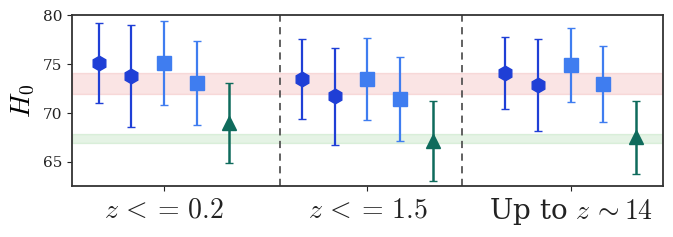

In [10]:
"""
Hubble Tension plot - replica del boceto de Holman.
Datos ESTIMADOS a partir de la imagen subida; reemplazar con valores reales
del análisis (L-sigma relation, GEHR/HIIG, etc.) cuando estén disponibles.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ---------------------------------------------------------------
# 1. DATOS ESTIMADOS (editar aquí con tus valores reales)
# ---------------------------------------------------------------

# --- Bandas de referencia (Planck/LambdaCDM vs SH0ES/Distance Ladder) ---

PLANCK_H0, PLANCK_ERR = 67.4, 0.5
SHOES_H0, SHOES_ERR = 73.04, 1.04

# --- Panel inferior: Evolución con z para "This work" ---
# 3 grupos en z = 0.2, 1.5, 14 ; cada grupo: no-metal, metal, TRGB
z_groups = [0.2, 1.5, 14]
z_offsets = [-0.6, -0.2, 0.2, 0.6]  # no-metal x2, metal x2 dentro de cada grupo (estimado del boceto)

eta_data = {
    0.2: {
        "nometal": [(75.1, 4.1), (73.8, 5.2)],
        "metal":   [(75.1, 4.3), (73.1, 4.3)],
        "trgb":    [(69.0, 4.1)],
    },
    1.5: {
        "nometal": [(73.5, 4.1), (71.7, 5.0)],
        "metal":   [(73.5, 4.2), (71.4, 4.3)],
        "trgb":    [(67.1, 4.1)],
    },
    14: {
        "nometal": [(74.1, 3.7), (72.9, 4.7)],
        "metal":   [(74.9, 3.8), (73.0, 3.9)],
        "trgb":    [(67.5, 3.7)],
    },
}

# ---------------------------------------------------------------
# 2. ESTILO
# ---------------------------------------------------------------

COLOR_LCDM = "#2ca02c"       # verde - Historic LCDM
COLOR_DL = "#d62728"         # rojo - Historic Distance Ladder
COLOR_TRGB_HIST = "#17e0c4"  # cian - Historic TRGB
COLOR_NOMETAL = "#1f3fd6"    # azul oscuro - This work no-metalicity
COLOR_METAL = "#3f7df0"      # azul claro - This work metalicity
COLOR_TRGB_NEW = "#0f6b5c"   # verde oscuro - This work TRGB

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.3,
    "figure.facecolor": "white",
})


mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 317.1
target_height_mm = 110.76
# Invertimos las proporciones de la figura para hacerla alta
fig, ax_bot= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))
gs = GridSpec(1, 1)


# ---------------------------------------------------------------
# 3. PANEL SUPERIOR
# ---------------------------------------------------------------

# Bandas horizontales sombreadas

ax_bot.axhspan(PLANCK_H0 - PLANCK_ERR, PLANCK_H0 + PLANCK_ERR,
            color=COLOR_LCDM, alpha=0.12, zorder=0)
ax_bot.axhspan(SHOES_H0 - SHOES_ERR, SHOES_H0 + SHOES_ERR,
            color=COLOR_DL, alpha=0.12, zorder=0)
# ---------------------------------------------------------------
# 5. PANEL INFERIOR: evolución con z
# ---------------------------------------------------------------

xpos = []
xlabels = []
base = 0
group_centers = []

for gi, z in enumerate(z_groups):
    d = eta_data[z]
    n_nometal = len(d["nometal"])
    n_metal = len(d["metal"])
    n_trgb = len(d["trgb"])
    n_total = n_nometal + n_metal + n_trgb
    xs = base + np.arange(n_total) * 0.9
    idx = 0

    for (y, yerr) in d["nometal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="h", color=COLOR_NOMETAL,
                         ecolor=COLOR_NOMETAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["metal"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="s", color=COLOR_METAL,
                         ecolor=COLOR_METAL, elinewidth=1.6, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1
    for (y, yerr) in d["trgb"]:
        ax_bot.errorbar(xs[idx], y, yerr=yerr, fmt="^", color=COLOR_TRGB_NEW,
                         ecolor=COLOR_TRGB_NEW, elinewidth=1.8, capsize=3,
                         markersize=10.5, zorder=3)
        idx += 1

    group_centers.append(np.mean(xs))
    base = xs[-1] + 2.0  # espacio entre grupos

ax_bot.set_xticks(group_centers)
ax_bot.set_xticklabels([r"$z \,<=\,0.2$",r"$z \,<=\,1.5$",r"Up to $z \, \sim 14$"],fontsize = 20)
ax_bot.set_ylabel(r"$H_0$", fontsize=20)
ax_bot.set_ylim(62.5, 80)

ax_bot.axvline(5, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)
ax_bot.axvline(10, color="#555555", ls=(0, (4, 3)), lw=1.3, zorder=2)

ax_bot.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig("hubble_tension_lowerpanel.png", dpi=500, bbox_inches="tight",transparent = True)
print("OK - figura guardada")

In [11]:
def L_sigma_plotter(DF=None,ax=None,codeX=None,h=None,e_h=None):
        if DF is not None and ax is not None and h is not None and e_h is not None and codeX is not None:
            cosmo = FlatwCDM(H0=h*100.0, Om0=0.3, w0=-1.0)
            set_ = DF[(DF['origin_id'] == codeX)]
            markers = {
                0: "s",   # square
                1: "o",   # circle
                2: "D",   # diamond
                3: "^",   # triangle up
                4: "v",   # triangle down
                5: "x",   # x
                6: "*",   # star
                7: "P",   # filled plus
                8: "h",   # hexagon
            }

            colors = {
                0: "brown",
                1: "blue",
                2: "green",
                3: "red",
                4: "orange",
                5: "gray",
                6: "purple",
                7: "teal",
                8: "black",
            }
            samples = {
                0: "GEHR",
                1: "Local HIIG",
                2: "Liter.Mid-z",
                3: "VLT/X-shooter",
                4: "Keck/MOSFIRE",
                5: "VLT/KMOS",
                6: "JWST/NIRSpec",
                7: "VUDS/VANDELS",
                8: "ALMA+JWST/MIRI"
            }

            if len(set_) != 0 and codeX == 0.0:
                pc_to_cm = 3.08567758e18
                zeta = pc_to_cm 
                logL = np.log10(4*np.pi*(zeta)**2) + ((2*set_['z_or_mu'] +10)/5) + set_['log_f_Hbeta']
                e_logL = np.sqrt(((2/5)*set_['e_z_or_e_mu'])**2 + (set_['e_log_f_Hbeta'])**2)
                logSigma = set_['log_sigma']
                e_logSigma = set_['e_log_sigma']
                ax.errorbar(
                    logSigma,
                    logL,
                    color = colors[codeX],
                    xerr=e_logSigma,
                    yerr=e_logL,
                    fmt=markers[codeX],
                    linestyle="none",
                    label=samples[codeX],
                    alpha=0.3,
                    capsize=2,
                    markersize=6
                )
                return ax            

            if len(set_) != 0 and codeX != 0.0:
                #if mode == 'Local':
                Mpc_to_cm = 3.08567758e24
                #km_to_cm = 100000
                eta = Mpc_to_cm #* km_to_cm
                c = 299792.458 #km/s
                Ez = cosmo.efunc(set_['z_or_mu'])  # E(z) = H(z)/H0
                # I(z) = integral_0^z dz'/E(z') = (H0/c) * D_C(z)
                Iz = (cosmo.comoving_distance(set_['z_or_mu']) * cosmo.H0 / const.c).to_value(u.dimensionless_unscaled)
                logL = np.log10(4*np.pi*(eta)**2*c**2) - (2*np.log10(h*100)) + set_['log_f_Hbeta'] + (2*np.log10(1 + set_['z_or_mu']))  + (2*np.log10(Iz)) 
                e_logL = np.sqrt(((2.0/np.log(10.0)) * (1.0/(1.0+set_['z_or_mu']) + 1.0/(Ez*Iz)) * set_['e_z_or_e_mu'])**2 + (e_h * (-2/(h*np.log(10))))**2   + (set_['e_log_f_Hbeta'])**2)
                logSigma = set_['log_sigma']
                e_logSigma = set_['e_log_sigma']
                ax.errorbar(
                    logSigma,
                    logL,
                    color = colors[codeX],
                    xerr=e_logSigma,
                    yerr=e_logL,
                    fmt=markers[codeX],
                    linestyle="none",
                    label=samples[codeX],
                    alpha=0.3,
                    capsize=2,
                    markersize=5
                )
                #ax.scatter(logSigma, logL, s=set_['z_or_mu'], alpha=0.2, c=set_['z_or_mu'], cmap='viridis', edgecolors='black')
                return ax
            
            else:
                return 0

OK - figura guardada


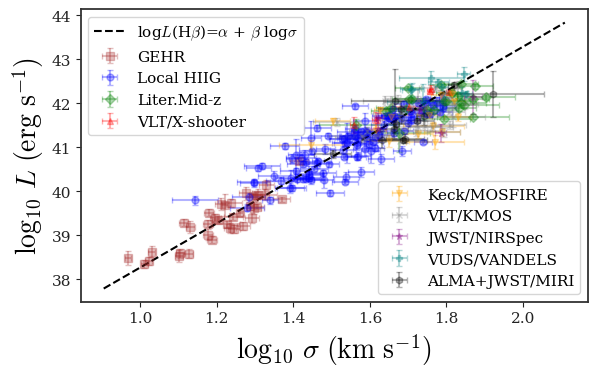

In [13]:
mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 274.45
target_height_mm = 172.27

# Lee datos L-sigma
LSdata_df = pd.read_csv(
    "Compilation2026_main.csv",
    comment="#",
    index_col=False,
    dtype={"GEHR_id": str},
)



# Invertimos las proporciones de la figura para hacerla alta
fig, ax = plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))

for obj in range(9):
    L_sigma_plotter(DF=LSdata_df,
                    ax=ax,
                    codeX=obj,
                    h=0.735,
                    e_h=8.1e-3)

xmin, xmax = ax.get_xlim()
x_line = np.linspace(xmin-0.001, xmax, 100)
y_line = 5.02 * x_line + 33.25
ax.plot(x_line, y_line, label=r"log$L$(H$\beta$)=$\alpha$ + $\beta$ log$\sigma$", color = 'k', linestyle = '--')



ax.set_xlabel(r"$\log_{10}\, \sigma\ \mathrm{(km\ s^{-1})}$", fontsize = 20)
ax.set_ylabel(r"$\log_{10}\, L\ \mathrm{(erg\ s^{-1})}$", fontsize = 20)





handles_div, labels = ax.get_legend_handles_labels()

leyenda_izquierda = ax.legend(ncol=1,handles=handles_div[0:5], loc='upper left')
ax.add_artist(leyenda_izquierda)
ax.legend(ncol=1,handles=handles_div[5:], loc='lower right')
ax.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig("Lsimga_x_poster.png", dpi=500, bbox_inches="tight",transparent = True)
print("OK - figura guardada")





In [18]:
LSdata_df = pd.read_csv(
    "Compilation2026.csv",
    comment="#",
    index_col=False,
    dtype={"GEHR_id": str},
)

len(LSdata_df[LSdata_df['origin_id'] != 0.0])

207

In [19]:
len(LSdata_df)

243

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 2500
 dimensionality =    5
 resuming from previous job
 *****************************************************
  analysing data from /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_SMR/Five_Fc_Fs_.txt ln(ev)=  -440.72915793068915      +/-   7.3154417017725223E-002
 Total Likelihood Evaluations:        98647
 Sampling finished. Exiting MultiNest


Evidence lnZ = -440.729 ± 0.073
Posterior means/stdev:
\alpha: 33.193 ± 0.131
 \beta: 5.040 ± 0.107
     h: 0.741 ± 0.038
\Omega_m: 0.270 ± 0.093
w_{DE}: -0.956 ± 0.382
Removed no burn in
GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_SMR/Five_Fc_Fs_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_SMR


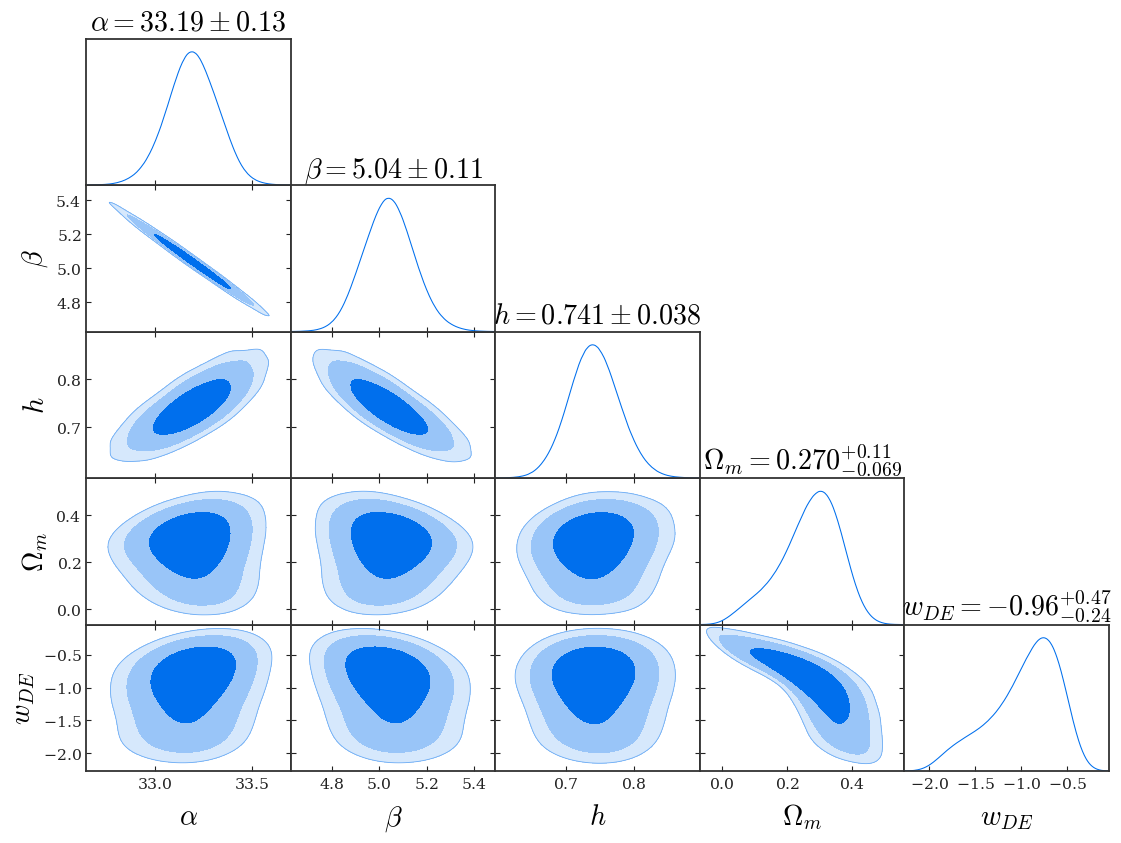

In [14]:
class Lsig_Ho_sampler:
    def __init__(self,
                 data_frame = None,
                 distance_estimator_set = None,
                 estimator_error_kind = None,
                 main_title = None,
                 folder_name = None,
                 analysis_mode = None,
                 id_prefix = None):
        
        self.data_frame = data_frame
        self.distance_estimator_set = distance_estimator_set
        self.estimator_error_kind = estimator_error_kind
        self.main_title = main_title
        self.folder_name = folder_name
        self.analysis_mode = analysis_mode
        self.id_prefix = id_prefix
        self.outdir = None
        self.prefix = None

        self.dir_results_creation()
        self.main_sampler()

    def dir_results_creation(self):
        self.outdir = os.path.join(os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Multinest'), f"{self.folder_name}")
        os.makedirs(self.outdir, exist_ok=True)
        self.prefix = os.path.join(self.outdir, f"{self.id_prefix}_")



    def group_reader(self, DF=None, group=None, error_kind = None):

        if DF != None and group != None and error_kind != None:
            DF_pd = DF.to_pandas()
            df_group = pd.read_csv(group)
            galaxies_in_group = df_group['Galaxia'].unique()
            filtro = DF_pd[DF_pd['GEHR_id'].isin(galaxies_in_group) | (DF_pd['origin_id'] > 0.0)].copy()
            filtro = filtro.merge(
                df_group[['Galaxia', 'mu_w', f'{error_kind}']], 
                left_on='GEHR_id', 
                right_on='Galaxia', 
                how='left'
            )
            coincide = filtro['mu_w'].notna()
            filtro.loc[coincide, 'z_or_mu'] = filtro.loc[coincide, 'mu_w']
            filtro.loc[coincide, 'e_z_or_e_mu'] = filtro.loc[coincide, f'{error_kind}']
            filtro = filtro.drop(columns=['Galaxia', 'mu_w', f'{error_kind}'])
            new_DF = Table.from_pandas(filtro)
            return new_DF
        else:
            return None



    def lnlike(self,theta=None,DF=None,z_range = None):

        if theta is not None and DF is not None and z_range is not None:
            alpha, beta, h0, Om, wDE = theta
            cosmo = FlatwCDM(H0=h0*100.0, Om0=Om, w0=wDE)


            def D_L(cosmo,z,universe_antiquity):
                if universe_antiquity == 'Low':
                    d_l = (const.c.to(u.km/u.s) / cosmo.H0) * z
                    return d_l.value

                if universe_antiquity == 'Moderate':
                    q0 = cosmo.Om0 / 2.0 - cosmo.Ode0
                    d_l = (const.c.to(u.km/u.s) / cosmo.H0) * (z + ((1/2)*(1-q0)*(z**2)) )    
                    return d_l.value
                
                if universe_antiquity == 'High':
                    z = np.atleast_1d(np.asarray(z, dtype=float))
                    d_l = cosmo.luminosity_distance(z).value
                    return d_l

            def dmu_dz(cosmo,z,universe_antiquity):

                if universe_antiquity == 'Low':
                    return (5.0/np.log(10.0))*(1/z)

                if universe_antiquity == 'Moderate':
                    #Om_z = cosmo.Om(z)
                    #Ode_z = cosmo.Ode(z)
                    #q = (Om_z / 2.0) - Ode_z
                    #return (10* ((q-1)*z-1) ) / (z * np.log(10) * ((q-1)*z-2))

                    q0 = cosmo.Om0 / 2.0 - cosmo.Ode0
                    return (10* ((q0-1)*z-1) ) / (z * np.log(10) * ((q0-1)*z-2))


                
                if universe_antiquity == 'High':
                    z = np.atleast_1d(np.asarray(z, dtype=float))
                    Ez = cosmo.efunc(z)  # E(z) = H(z)/H0
                    # I(z) = integral_0^z dz'/E(z') = (H0/c) * D_C(z)
                    Iz = (cosmo.comoving_distance(z) * cosmo.H0 / const.c.to(u.km/u.s)).to_value(u.dimensionless_unscaled)
                    return np.abs((5.0/np.log(10.0)) * (1.0/(1.0+z) + 1.0/(Ez*Iz)))


            G = DF['origin_id'] == 0.0
            H = DF['origin_id'] != 0.0

            Mum = DF['z_or_mu'] * 0.0
            MumErr = DF['e_z_or_e_mu'] * 0.0

            Mum[G] = DF[G]['z_or_mu']
            MumErr[G] = DF[G]['e_z_or_e_mu']
            
            Mum[H] = 5.0*np.log10(D_L(cosmo, DF[H]['z_or_mu'],z_range)) + 25.0
            MumErr[H] =  dmu_dz(cosmo, DF[H]['z_or_mu'],z_range) * DF[H]['e_z_or_e_mu']

            Mu = 2.5*(beta*DF['log_sigma'] + alpha) - 2.5*DF['log_f_Hbeta'] - 100.19477738511641 
            MuErr = 2.5*np.sqrt((DF['e_log_f_Hbeta'])**2 + beta**2*(DF['e_log_sigma'])**2)

            R = (Mu - Mum)
            W = 1.0/(MuErr**2 + MumErr**2)

            xsq = np.sum(R**2 * W)
            llq = -0.5*xsq
            return llq
        else:
            return None




    def main_sampler(self):

        concat_filter_DF = self.group_reader(DF = self.data_frame,
                                   group = self.distance_estimator_set,
                                   error_kind = self.estimator_error_kind)

        def prior_transform(u):
            alpha = 20.0 + 20.0 * u[0]     # 20->40
            beta  =  0.0 + 10.0 * u[1]     # 0->10
            h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
            Om    =  0.0 +  1.0 * u[3]     # 0.2->0.7
            wDE   = -2.0 +  3.0 * u[4]     # -1.0->1.0
            return np.array([alpha, beta, h0, Om, wDE])

        def loglike(theta):
            return self.lnlike(theta = theta,
                               DF = concat_filter_DF,
                               z_range = self.analysis_mode)

        n_dims = 5
        result = pymultinest.solve(
            LogLikelihood=loglike,
            Prior=prior_transform,
            n_dims=n_dims,
            outputfiles_basename=self.prefix,
            evidence_tolerance=0.5,
            n_live_points=2500,
            multimodal=True,
            verbose=False
        )


        print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))


        samples = result["samples"]   # shape = (Nsamples, 3)
        parameters = [r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"]
        print("Posterior means/stdev:")
        for name, col in zip(parameters, samples.T):
            print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


        with open(self.prefix + "params.json", "w") as f:
            json.dump(parameters, f, indent=2)

        #fig = corner.corner(
        #    samples,
        #    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
        #    show_titles=True,
        #    title_fmt=".3f",
        #    quantiles=[0.16, 0.5, 0.84]
        #)
        #fig.savefig(self.prefix + "corner.png", dpi=150, bbox_inches="tight")
        #plt.close(fig)
        #print("Corner guardado en:", self.prefix + "corner.png")



        mm_to_inch = 1 / 25.4
        # Target size in mm (e.g., 200mm width, 100mm height)
        target_width_mm = 335.16
        target_height_mm = 241.61


        # Invertimos las proporciones de la figura para hacerla alta
        #fig, ax = plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))


        gds = MCSamples(
            samples=samples,
            names=["alpha", "beta", "h","Om","wDE"],
            labels=[r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"] 
        )
        #g = plots.getSubplotPlotter()
        #g.settings.num_plot_contours = 4
        #g.triangle_plot([gds], filled=True, title_limit=1)

        g = plots.get_subplot_plotter(width_inch=target_width_mm*mm_to_inch)

        g.settings.num_plot_contours = 4
        # Ajustar la proporción altura/ancho de los subplots para coincidir con tu alto deseado
        g.settings.subplot_size_ratio = target_height_mm / target_width_mm

        g.settings.axes_labelsize = 22          # Letras de los parámetros (\alpha, \beta, etc.)
        g.settings.axes_fontsize = 13           # Números de los ejes (0.1, 0.2, etc.)
        g.settings.title_limit_fontsize = 22    # Texto de los límites arriba de cada 1D


        # 4. Dibujar el triángulo directamente (creará la figura perfecta automáticamente)
        g.triangle_plot([gds], filled=True, title_limit=1)




        plt.savefig(
            self.prefix + "triangle_getdist.png", 
            bbox_inches='tight', 
            #bbox_extra_artists=[titulo],
            dpi=500,
            transparent=True
        )
        #plt.close(g.fig)

        print("GetDist triangle en:", self.prefix + "triangle_getdist.png")

        print("\nListo. Archivos en:", self.outdir)



def select_redshift_cut(tab, zmax):
    """
    Mantiene siempre la muestra ancla origin_id == 0.
    Para objetos no-ancla, aplica z_or_mu <= zmax.
    Si zmax is None, usa todos los objetos.
    """

    origin = np.asarray(tab["origin_id"], dtype=float)

    if zmax is None:
        mask = np.ones(len(tab), dtype=bool)
    else:
        z_or_mu = np.asarray(tab["z_or_mu"], dtype=float)

        mask = (
            (origin == 0.0)
            |
            ((origin != 0.0) & (z_or_mu <= zmax))
        )

    return tab[mask]



# Lee datos L-sigma
LSdata_df = pd.read_csv(
    "Compilation2026_Ch12data.csv",
    comment="#",
    index_col=False,
    dtype={"GEHR_id": str},
)

LS_tab = Table.from_pandas(LSdata_df)

data_cut = select_redshift_cut(LS_tab, 7)


Lsig_Ho_sampler(
    data_frame=data_cut,
    distance_estimator_set='sm_r.csv',
    estimator_error_kind='sigma_w',
    main_title="L-sigma test: HM 5 parameters",
    folder_name="Five_par_Full_SMR",
    analysis_mode='High',
    id_prefix='Five_Fc_Fs',
)


/tmp/ipykernel_2021780/2683608418.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


OK - figura guardada


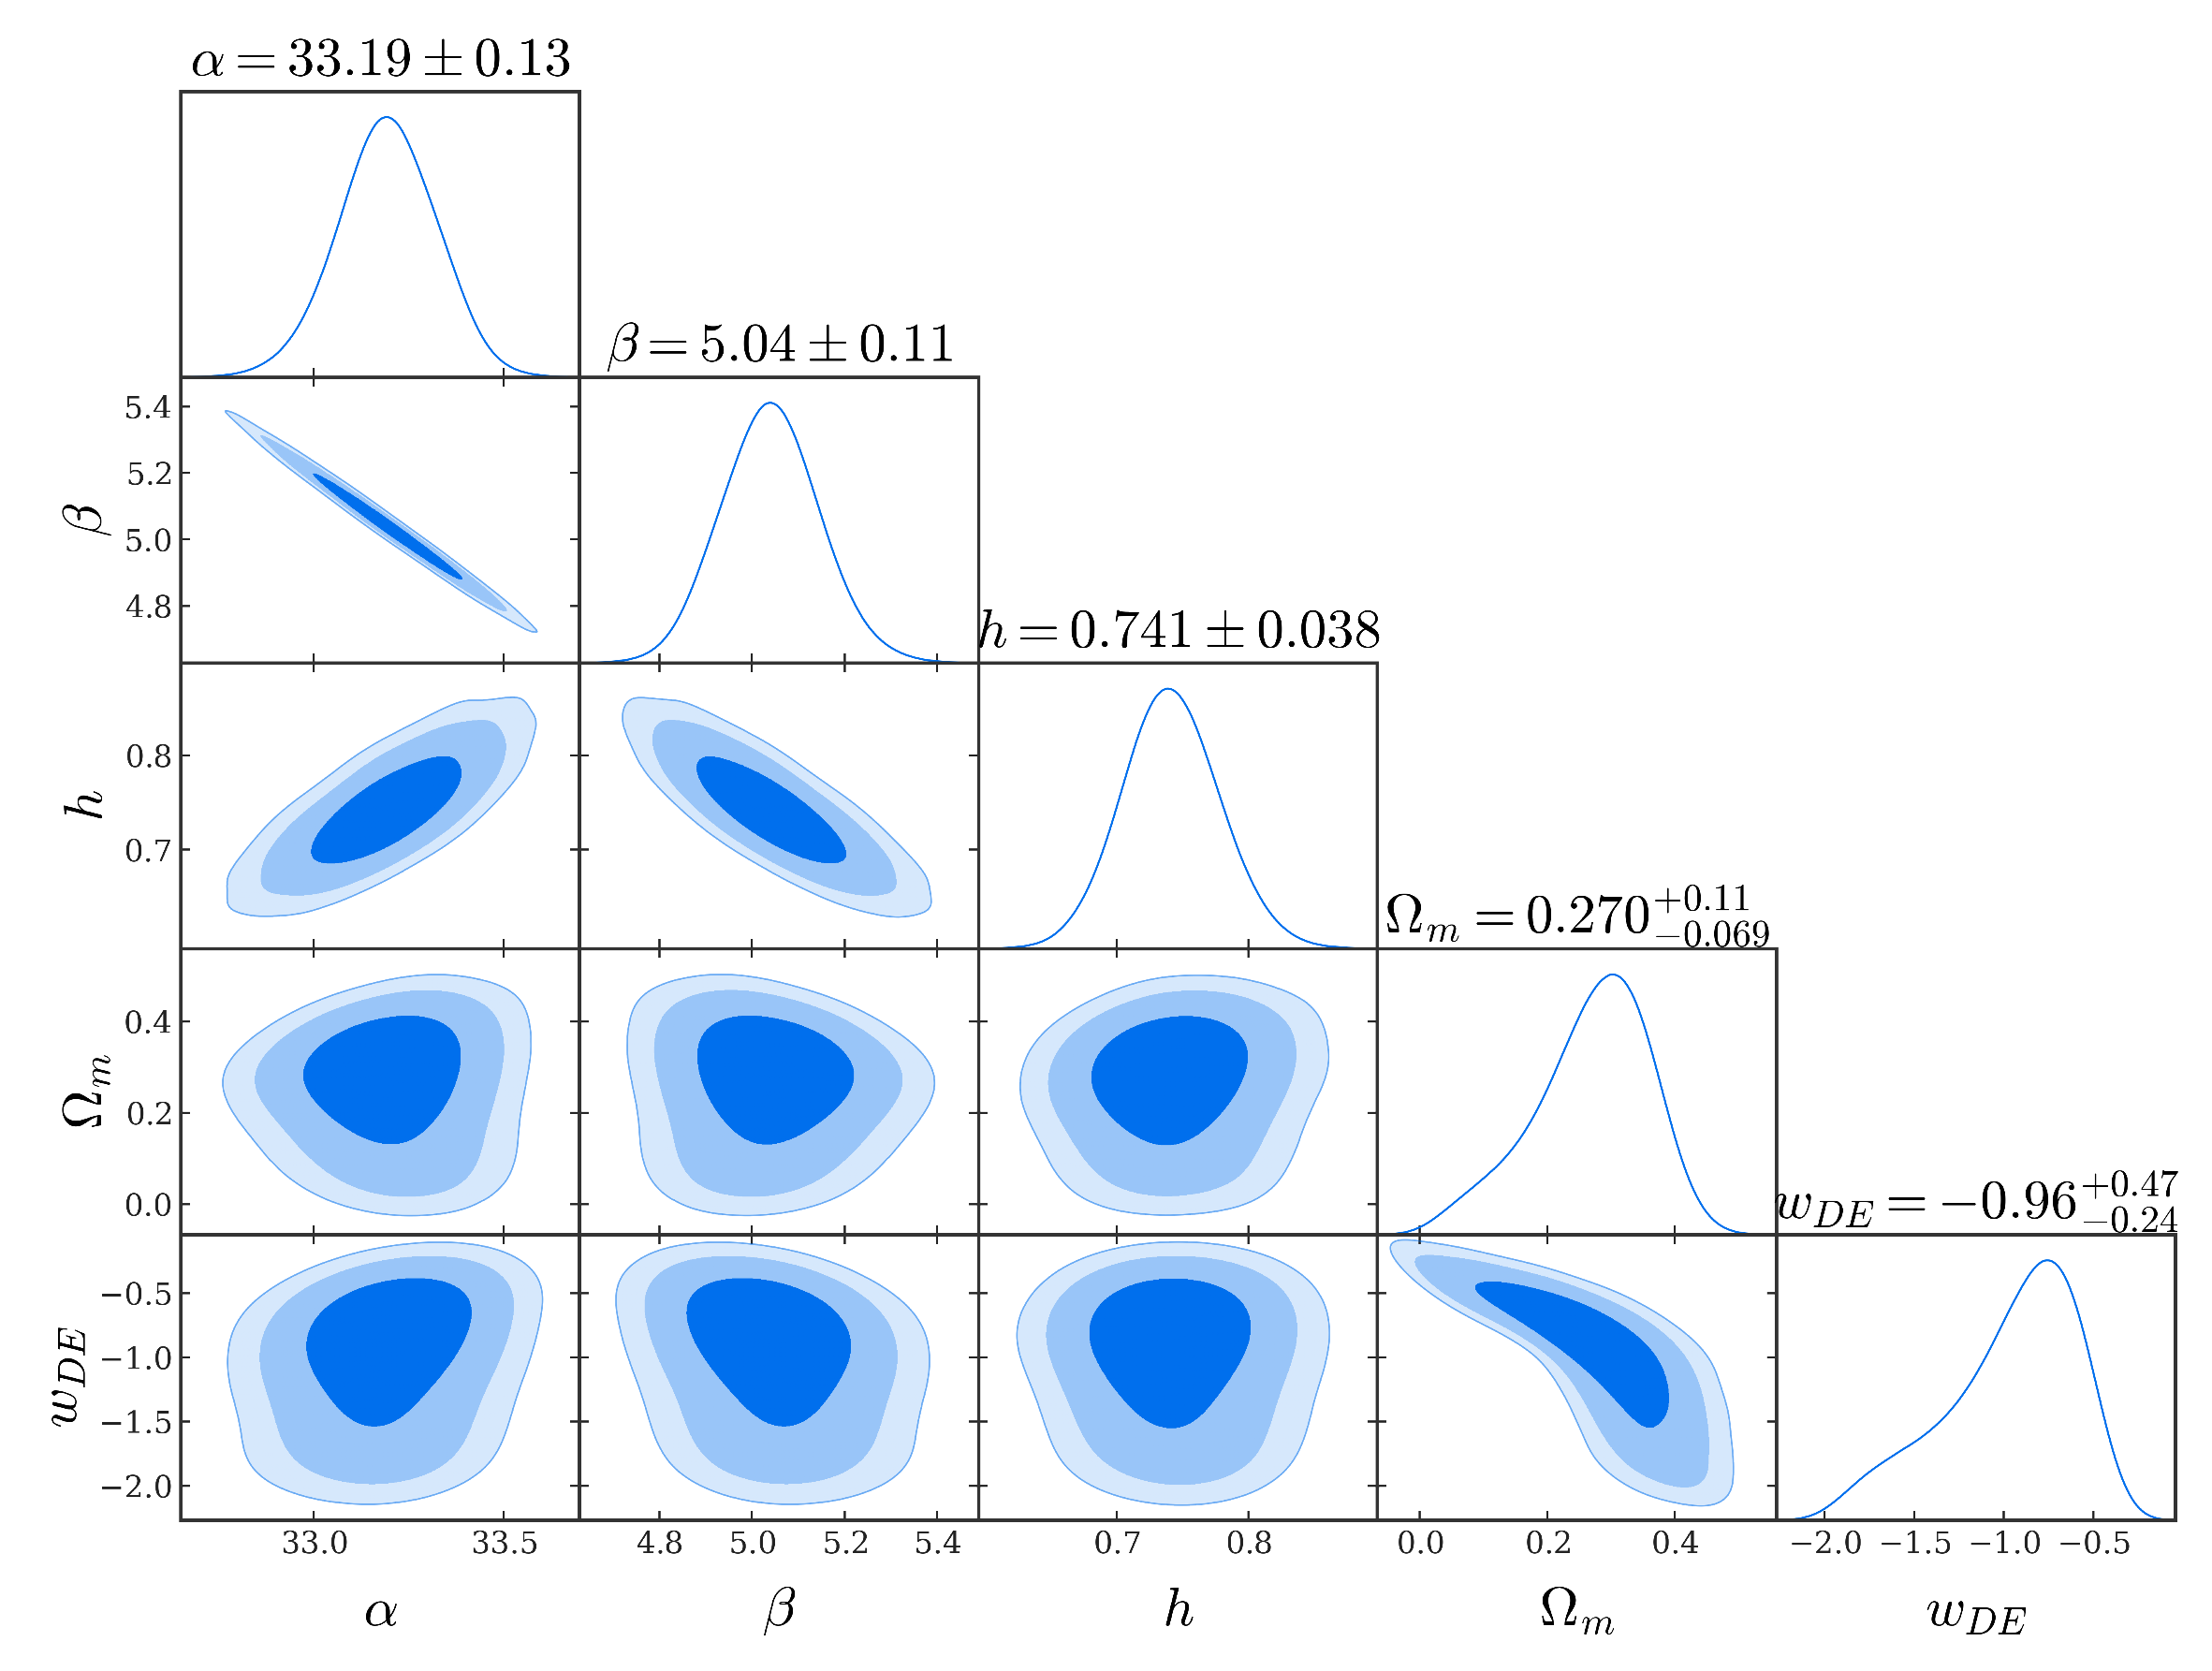

In [15]:
mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 335.16
target_height_mm = 241.61
# Invertimos las proporciones de la figura para hacerla alta
fig, ax= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))

img_path = '/home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_SMR/Five_Fc_Fs_triangle_getdist.png'
img = mpimg.imread(img_path)
imagebox = OffsetImage(img, zoom=0.30)  # Ajusta el zoom según el tamaño deseado

ab = AnnotationBbox(
    imagebox,
    (0.5, 0.5),                # ¡Modificado!: Centro exacto de las coordenadas (X, Y)
    xycoords="axes fraction",  # 0-1 respecto al área total del plot
    box_alignment=(0.5, 0.5),  # ¡Modificado!: Ancla centrada en los ejes X e Y de la propia imagen
    frameon=False
)
ax.add_artist(ab)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig("Hubble_params_corner_plotSMR.png", dpi=500, bbox_inches="tight",transparent = True)
print("OK - figura guardada")



 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 2500
 dimensionality =    5
 resuming from previous job
 *****************************************************
  analysing data from /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_TR/Five_Fc_Fs_.txt ln(ev)=  -444.68949813648118      +/-   7.2757346313898116E-002
 Total Likelihood Evaluations:       100578
 Sampling finished. Exiting MultiNest


Evidence lnZ = -444.689 ± 0.073
Posterior means/stdev:
\alpha: 33.300 ± 0.132
 \beta: 5.014 ± 0.110
     h: 0.686 ± 0.038
\Omega_m: 0.270 ± 0.095
w_{DE}: -0.929 ± 0.375
Removed no burn in


GetDist triangle en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_TR/Five_Fc_Fs_triangle_getdist.png

Listo. Archivos en: /home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_TR


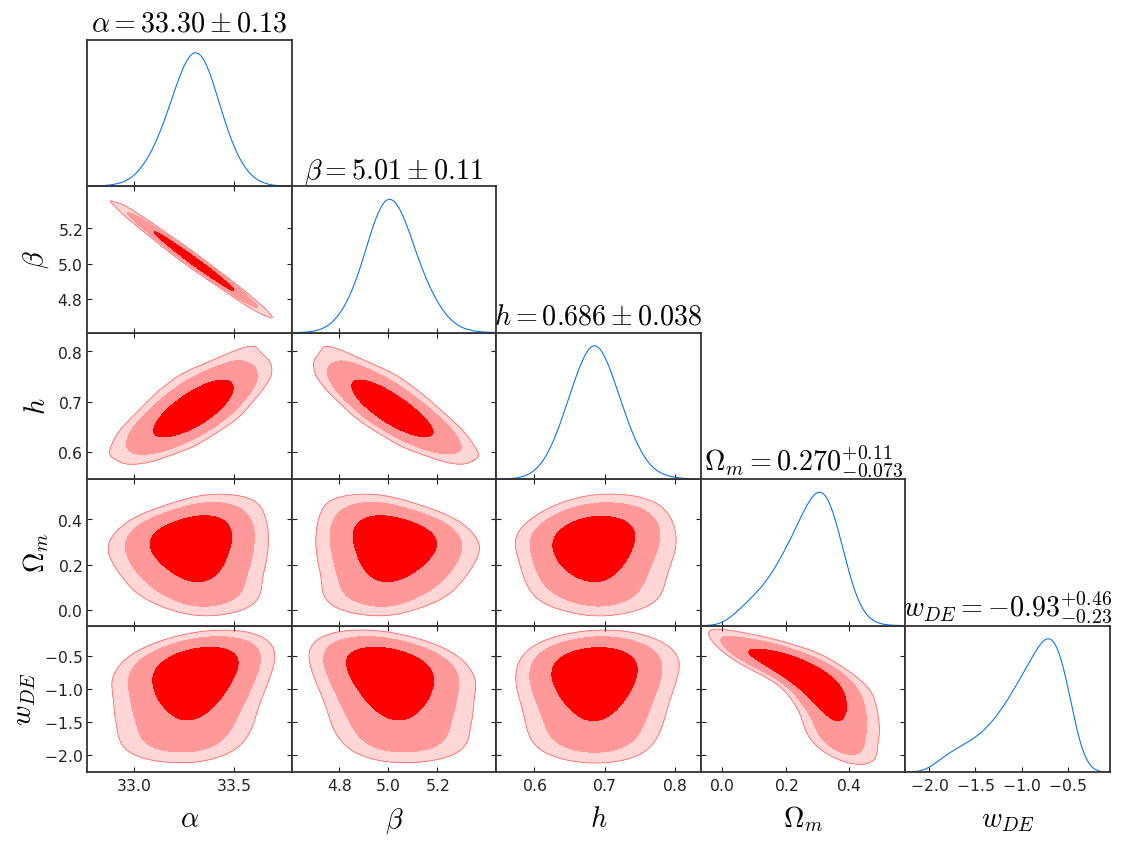

In [20]:
class Lsig_Ho_sampler:
    def __init__(self,
                 data_frame = None,
                 distance_estimator_set = None,
                 estimator_error_kind = None,
                 main_title = None,
                 folder_name = None,
                 analysis_mode = None,
                 id_prefix = None):
        
        self.data_frame = data_frame
        self.distance_estimator_set = distance_estimator_set
        self.estimator_error_kind = estimator_error_kind
        self.main_title = main_title
        self.folder_name = folder_name
        self.analysis_mode = analysis_mode
        self.id_prefix = id_prefix
        self.outdir = None
        self.prefix = None

        self.dir_results_creation()
        self.main_sampler()

    def dir_results_creation(self):
        self.outdir = os.path.join(os.path.expanduser('~/HIIGalaxies/Bayesian_samplers/Multinest'), f"{self.folder_name}")
        os.makedirs(self.outdir, exist_ok=True)
        self.prefix = os.path.join(self.outdir, f"{self.id_prefix}_")



    def group_reader(self, DF=None, group=None, error_kind = None):

        if DF != None and group != None and error_kind != None:
            DF_pd = DF.to_pandas()
            df_group = pd.read_csv(group)
            galaxies_in_group = df_group['Galaxia'].unique()
            filtro = DF_pd[DF_pd['GEHR_id'].isin(galaxies_in_group) | (DF_pd['origin_id'] > 0.0)].copy()
            filtro = filtro.merge(
                df_group[['Galaxia', 'mu_w', f'{error_kind}']], 
                left_on='GEHR_id', 
                right_on='Galaxia', 
                how='left'
            )
            coincide = filtro['mu_w'].notna()
            filtro.loc[coincide, 'z_or_mu'] = filtro.loc[coincide, 'mu_w']
            filtro.loc[coincide, 'e_z_or_e_mu'] = filtro.loc[coincide, f'{error_kind}']
            filtro = filtro.drop(columns=['Galaxia', 'mu_w', f'{error_kind}'])
            new_DF = Table.from_pandas(filtro)
            return new_DF
        else:
            return None



    def lnlike(self,theta=None,DF=None,z_range = None):

        if theta is not None and DF is not None and z_range is not None:
            alpha, beta, h0, Om, wDE = theta
            cosmo = FlatwCDM(H0=h0*100.0, Om0=Om, w0=wDE)


            def D_L(cosmo,z,universe_antiquity):
                if universe_antiquity == 'Low':
                    d_l = (const.c.to(u.km/u.s) / cosmo.H0) * z
                    return d_l.value

                if universe_antiquity == 'Moderate':
                    q0 = cosmo.Om0 / 2.0 - cosmo.Ode0
                    d_l = (const.c.to(u.km/u.s) / cosmo.H0) * (z + ((1/2)*(1-q0)*(z**2)) )    
                    return d_l.value
                
                if universe_antiquity == 'High':
                    z = np.atleast_1d(np.asarray(z, dtype=float))
                    d_l = cosmo.luminosity_distance(z).value
                    return d_l

            def dmu_dz(cosmo,z,universe_antiquity):

                if universe_antiquity == 'Low':
                    return (5.0/np.log(10.0))*(1/z)

                if universe_antiquity == 'Moderate':
                    #Om_z = cosmo.Om(z)
                    #Ode_z = cosmo.Ode(z)
                    #q = (Om_z / 2.0) - Ode_z
                    #return (10* ((q-1)*z-1) ) / (z * np.log(10) * ((q-1)*z-2))

                    q0 = cosmo.Om0 / 2.0 - cosmo.Ode0
                    return (10* ((q0-1)*z-1) ) / (z * np.log(10) * ((q0-1)*z-2))


                
                if universe_antiquity == 'High':
                    z = np.atleast_1d(np.asarray(z, dtype=float))
                    Ez = cosmo.efunc(z)  # E(z) = H(z)/H0
                    # I(z) = integral_0^z dz'/E(z') = (H0/c) * D_C(z)
                    Iz = (cosmo.comoving_distance(z) * cosmo.H0 / const.c.to(u.km/u.s)).to_value(u.dimensionless_unscaled)
                    return np.abs((5.0/np.log(10.0)) * (1.0/(1.0+z) + 1.0/(Ez*Iz)))


            G = DF['origin_id'] == 0.0
            H = DF['origin_id'] != 0.0

            Mum = DF['z_or_mu'] * 0.0
            MumErr = DF['e_z_or_e_mu'] * 0.0

            Mum[G] = DF[G]['z_or_mu']
            MumErr[G] = DF[G]['e_z_or_e_mu']
            
            Mum[H] = 5.0*np.log10(D_L(cosmo, DF[H]['z_or_mu'],z_range)) + 25.0
            MumErr[H] =  dmu_dz(cosmo, DF[H]['z_or_mu'],z_range) * DF[H]['e_z_or_e_mu']

            Mu = 2.5*(beta*DF['log_sigma'] + alpha) - 2.5*DF['log_f_Hbeta'] - 100.19477738511641 
            MuErr = 2.5*np.sqrt((DF['e_log_f_Hbeta'])**2 + beta**2*(DF['e_log_sigma'])**2)

            R = (Mu - Mum)
            W = 1.0/(MuErr**2 + MumErr**2)

            xsq = np.sum(R**2 * W)
            llq = -0.5*xsq
            return llq
        else:
            return None




    def main_sampler(self):

        concat_filter_DF = self.group_reader(DF = self.data_frame,
                                   group = self.distance_estimator_set,
                                   error_kind = self.estimator_error_kind)

        def prior_transform(u):
            alpha = 20.0 + 20.0 * u[0]     # 20->40
            beta  =  0.0 + 10.0 * u[1]     # 0->10
            h0    =  0.5 +  0.5 * u[2]     # 0.5->1.0
            Om    =  0.0 +  1.0 * u[3]     # 0.2->0.7
            wDE   = -2.0 +  3.0 * u[4]     # -1.0->1.0
            return np.array([alpha, beta, h0, Om, wDE])

        def loglike(theta):
            return self.lnlike(theta = theta,
                               DF = concat_filter_DF,
                               z_range = self.analysis_mode)

        n_dims = 5
        result = pymultinest.solve(
            LogLikelihood=loglike,
            Prior=prior_transform,
            n_dims=n_dims,
            outputfiles_basename=self.prefix,
            evidence_tolerance=0.5,
            n_live_points=2500,
            multimodal=True,
            verbose=False
        )


        print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))


        samples = result["samples"]   # shape = (Nsamples, 3)
        parameters = [r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"]
        print("Posterior means/stdev:")
        for name, col in zip(parameters, samples.T):
            print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")


        with open(self.prefix + "params.json", "w") as f:
            json.dump(parameters, f, indent=2)

        #fig = corner.corner(
        #    samples,
        #    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
        #    show_titles=True,
        #    title_fmt=".3f",
        #    quantiles=[0.16, 0.5, 0.84]
        #)
        #fig.savefig(self.prefix + "corner.png", dpi=150, bbox_inches="tight")
        #plt.close(fig)
        #print("Corner guardado en:", self.prefix + "corner.png")



        mm_to_inch = 1 / 25.4
        # Target size in mm (e.g., 200mm width, 100mm height)
        target_width_mm = 335.16
        target_height_mm = 241.61


        # Invertimos las proporciones de la figura para hacerla alta
        #fig, ax = plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))


        gds = MCSamples(
            samples=samples,
            names=["alpha", "beta", "h","Om","wDE"],
            labels=[r"\alpha", r"\beta", r"h",r"\Omega_m",r"w_{DE}"] 
        )
        #g = plots.getSubplotPlotter()
        #g.settings.num_plot_contours = 4
        #g.triangle_plot([gds], filled=True, title_limit=1)

        g = plots.get_subplot_plotter(width_inch=target_width_mm*mm_to_inch)

        g.settings.num_plot_contours = 4
        # Ajustar la proporción altura/ancho de los subplots para coincidir con tu alto deseado
        g.settings.subplot_size_ratio = target_height_mm / target_width_mm

        g.settings.axes_labelsize = 22          # Letras de los parámetros (\alpha, \beta, etc.)
        g.settings.axes_fontsize = 13           # Números de los ejes (0.1, 0.2, etc.)
        g.settings.title_limit_fontsize = 22    # Texto de los límites arriba de cada 1D


        # 4. Dibujar el triángulo directamente (creará la figura perfecta automáticamente)
        g.triangle_plot([gds], filled=True, title_limit=1, colors = ['red'])




        plt.savefig(
            self.prefix + "triangle_getdist.png", 
            bbox_inches='tight', 
            #bbox_extra_artists=[titulo],
            dpi=500,
            transparent=True
        )
        #plt.close(g.fig)

        print("GetDist triangle en:", self.prefix + "triangle_getdist.png")

        print("\nListo. Archivos en:", self.outdir)



def select_redshift_cut(tab, zmax):
    """
    Mantiene siempre la muestra ancla origin_id == 0.
    Para objetos no-ancla, aplica z_or_mu <= zmax.
    Si zmax is None, usa todos los objetos.
    """

    origin = np.asarray(tab["origin_id"], dtype=float)

    if zmax is None:
        mask = np.ones(len(tab), dtype=bool)
    else:
        z_or_mu = np.asarray(tab["z_or_mu"], dtype=float)

        mask = (
            (origin == 0.0)
            |
            ((origin != 0.0) & (z_or_mu <= zmax))
        )

    return tab[mask]



# Lee datos L-sigma
LSdata_df = pd.read_csv(
    "Compilation2026_Ch12data.csv",
    comment="#",
    index_col=False,
    dtype={"GEHR_id": str},
)

LS_tab = Table.from_pandas(LSdata_df)

data_cut = select_redshift_cut(LS_tab, 7)


Lsig_Ho_sampler(
    data_frame=data_cut,
    distance_estimator_set='t_r.csv',
    estimator_error_kind='sigma_w',
    main_title="L-sigma test: HM 5 parameters",
    folder_name="Five_par_Full_TR",
    analysis_mode='High',
    id_prefix='Five_Fc_Fs',
)


/tmp/ipykernel_2021780/3866749547.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


OK - figura guardada


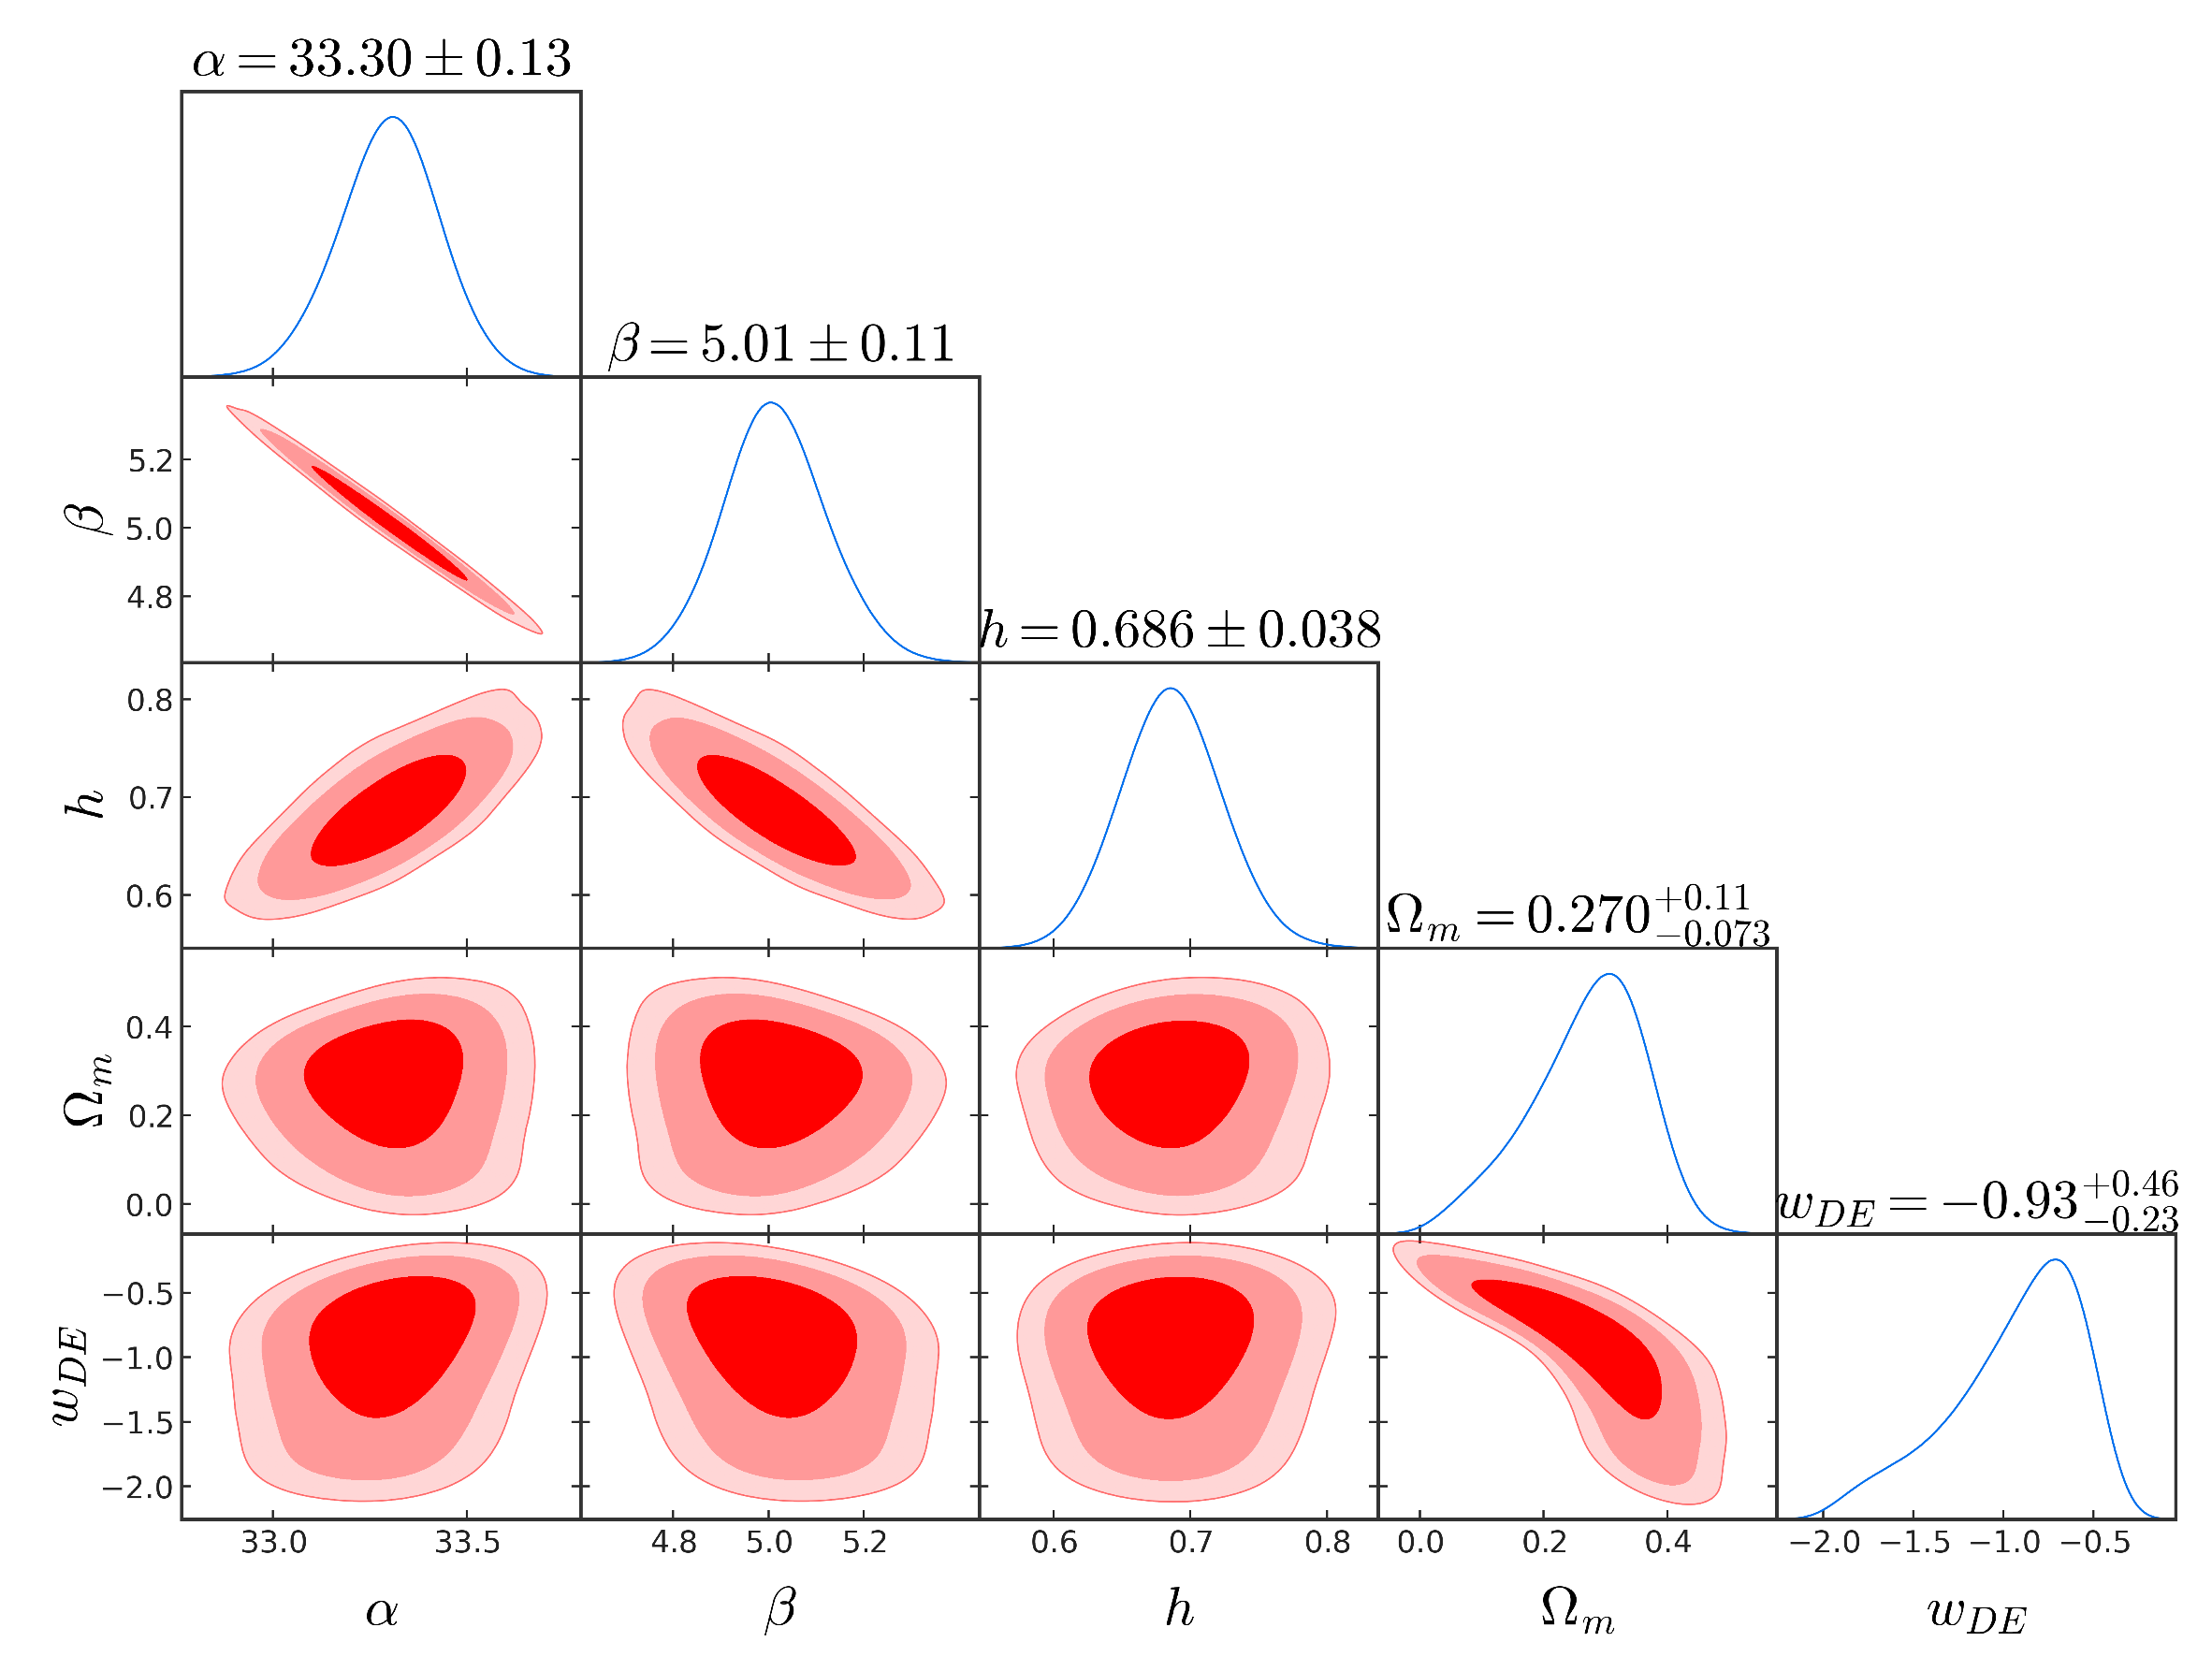

In [21]:
mm_to_inch = 1 / 25.4
# Target size in mm (e.g., 200mm width, 100mm height)
target_width_mm = 335.16
target_height_mm = 241.61
# Invertimos las proporciones de la figura para hacerla alta
fig, ax= plt.subplots(figsize=(target_width_mm * mm_to_inch,target_height_mm * mm_to_inch))

img_path = '/home/holman/HIIGalaxies/Bayesian_samplers/Multinest/Five_par_Full_TR/Five_Fc_Fs_triangle_getdist.png'
img = mpimg.imread(img_path)
imagebox = OffsetImage(img, zoom=0.30)  # Ajusta el zoom según el tamaño deseado

ab = AnnotationBbox(
    imagebox,
    (0.5, 0.5),                # ¡Modificado!: Centro exacto de las coordenadas (X, Y)
    xycoords="axes fraction",  # 0-1 respecto al área total del plot
    box_alignment=(0.5, 0.5),  # ¡Modificado!: Ancla centrada en los ejes X e Y de la propia imagen
    frameon=False
)
ax.add_artist(ab)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_position([0.7, 0.7, 0.7, 0.7])

plt.tight_layout() 
plt.savefig("Hubble_params_corner_plotTR.png", dpi=500, bbox_inches="tight",transparent = True)
print("OK - figura guardada")



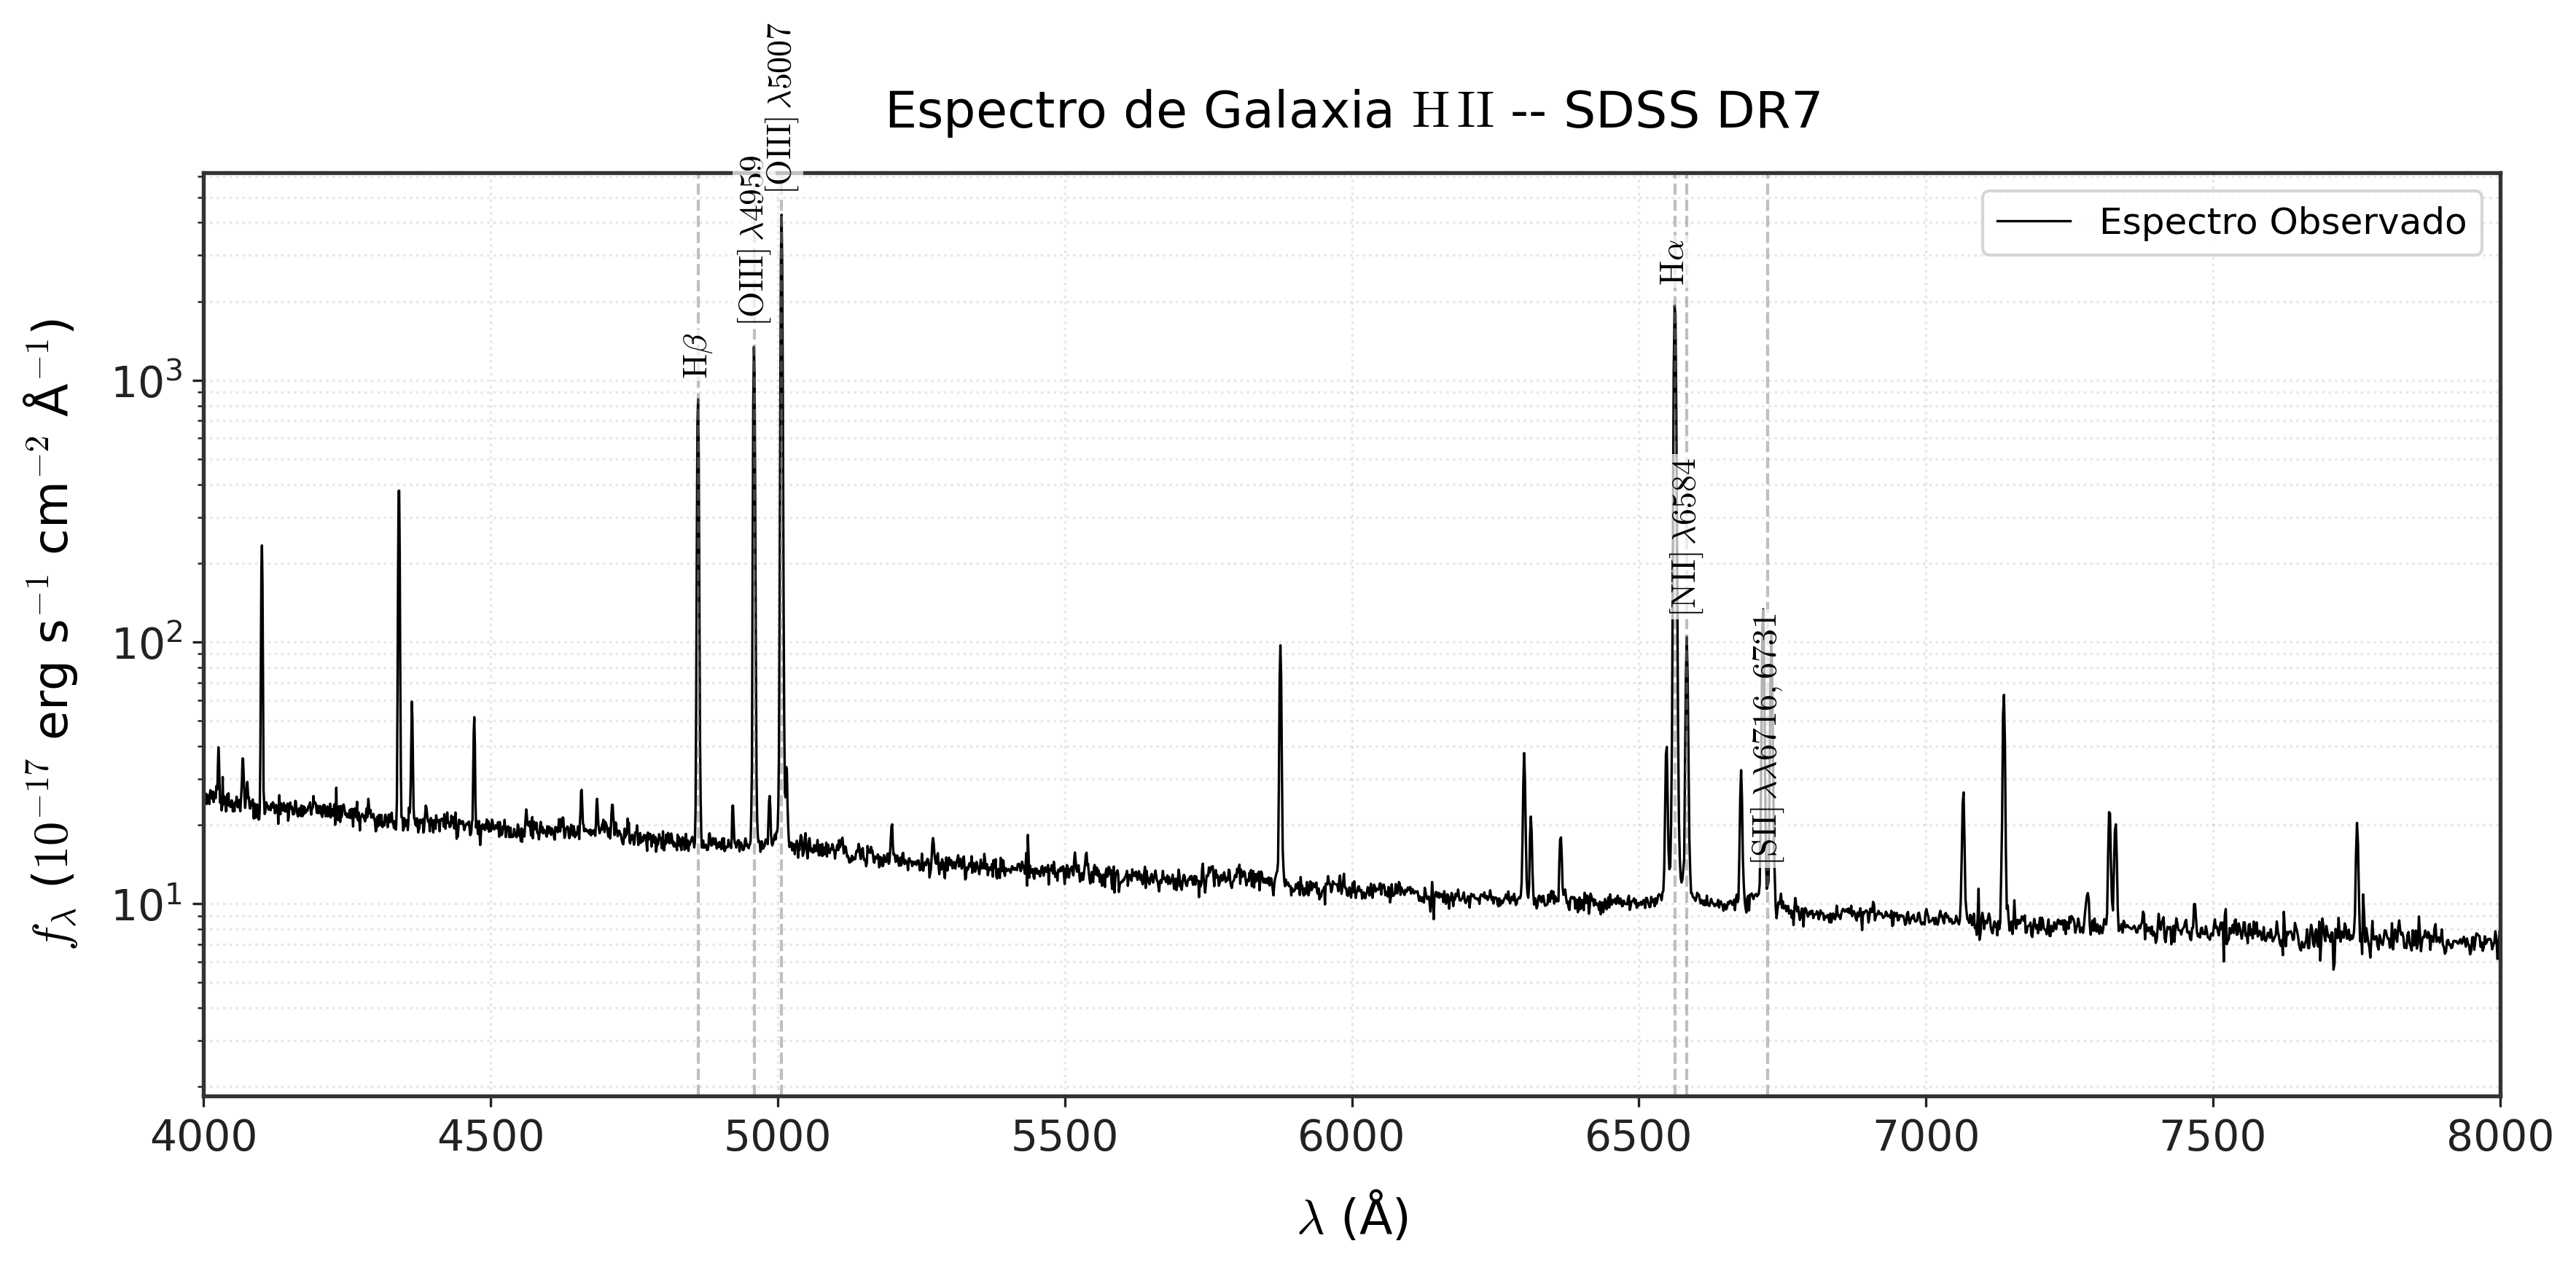

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Configuración de estilo tipo LaTeX para póster científico
plt.rcParams.update({
    "text.usetex": False,            # Habilita el renderizado de LaTeX
    "font.family": "serif",         # Tipografía con serifas clásica de LaTeX
    "font.serif": ["Computer Modern"], 
    "axes.labelsize": 16,           # Tamaño de etiquetas de los ejes
    "font.size": 14,                # Tamaño de fuente general
    "legend.fontsize": 12,          # Tamaño de la leyenda
    "xtick.labelsize": 14,          # Tamaño de números en el eje X
    "ytick.labelsize": 14,          # Tamaño de números en el eje Y
    "figure.titlesize": 18          # Tamaño del título principal
})

# 2. Cargar el archivo FITS de SDSS DR7
# Reemplaza 'espectro_dr7.fits' con la ruta de tu archivo descargado
fits_filename = '/home/holman/Data_storageHII/HIIG_specDR7/spSpec-51910-0275-445.fit'

with fits.open(fits_filename) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    zz = hdul[0].header['Z']
    # En SDSS DR7, los datos suelen extraerse de la tabla de la extensión 1
    # La longitud de onda está guardada en escala logarítmica base 10 (loglam)
    flux = data[0]
    wav00 = hdul[0].header['COEFF0']
    wavdiff = hdul[0].header['COEFF1']

    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))

    wavelength = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    wavelength = wavelength/(1.0+zz)
# 3. Definición de las líneas de emisión clave (Galaxia HII)
# Longitudes de onda en el aire (vacío/aire estándar)
lineas_emision = {
    r'$\mathrm{H}\beta$': 4861.3,
    r'$[\mathrm{OIII}]\,\lambda 4959$': 4958.9,
    r'$[\mathrm{OIII}]\,\lambda 5007$': 5006.8,
    r'$\mathrm{H}\alpha$': 6562.8,
    r'$[\mathrm{NII}]\,\lambda 6584$': 6583.4,
    r'$[\mathrm{SII}]\,\lambda\lambda 6716,6731$': 6724.0  # Promedio visual para el doblete
}

# 4. Crear la gráfica
fig, ax = plt.subplots(figsize=(12, 6), dpi=300) # Alta resolución para póster

# Graficar el espectro de la galaxia
ax.plot(wavelength, flux, color='black', lw=0.8, label='Espectro Observado')

# Configurar el rango del eje X (4000 a 8000 Angstroms)
ax.set_xlim(4000, 8000)

# Configurar el eje Y en escala logarítmica
ax.set_yscale('log')

# Etiquetas de los ejes usando formato matemático de LaTeX
ax.set_xlabel(r'$\lambda$ (Å)', labelpad=10)
ax.set_ylabel(r'$f_\lambda$ ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)', labelpad=10)
ax.set_title(r'Espectro de Galaxia $\mathrm{H\,II}$ -- SDSS DR7', pad=15)

# 5. Señalar de forma automática las líneas de emisión
# Filtramos el flujo en el rango visible para ajustar la altura del texto
mask = (wavelength >= 4000) & (wavelength <= 8000)
max_flux = np.max(flux[mask])

for nombre, wl in lineas_emision.items():
    # Dibujar una línea vertical discontinua gris en la posición de la línea
    ax.axvline(x=wl, color='gray', linestyle='--', alpha=0.5, lw=1)
    
    # Buscar el flujo local aproximado para posicionar bien la etiqueta de texto
    idx_cercano = np.abs(wavelength - wl).argmin()
    flujo_linea = flux[idx_cercano]
    
    # Desplazar el texto ligeramente hacia arriba del pico de la línea
    # Si el eje es logarítmico, multiplicamos para mantener una proporción visual
    pos_y = flujo_linea * 1.2 if flujo_linea > 0 else max_flux * 0.5
    
    # Evitar que el texto se salga por arriba de la gráfica
    if pos_y > max_flux * 2:
        pos_y = max_flux * 1.1

    ax.text(wl, pos_y, nombre, rotation=90, verticalalignment='bottom', 
            horizontalalignment='center', fontsize=11, 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Ajustes estéticos finales
ax.grid(True, which='both', linestyle=':', alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()

# Guardar la imagen optimizada para impresión de póster
plt.savefig('espectro_galaxia_hii.png', format='png', bbox_inches='tight', transparent=True, dpi=600)
plt.show()
